/usr/bin/python
LD_LIBRARY_PATH contains nvidia: False
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


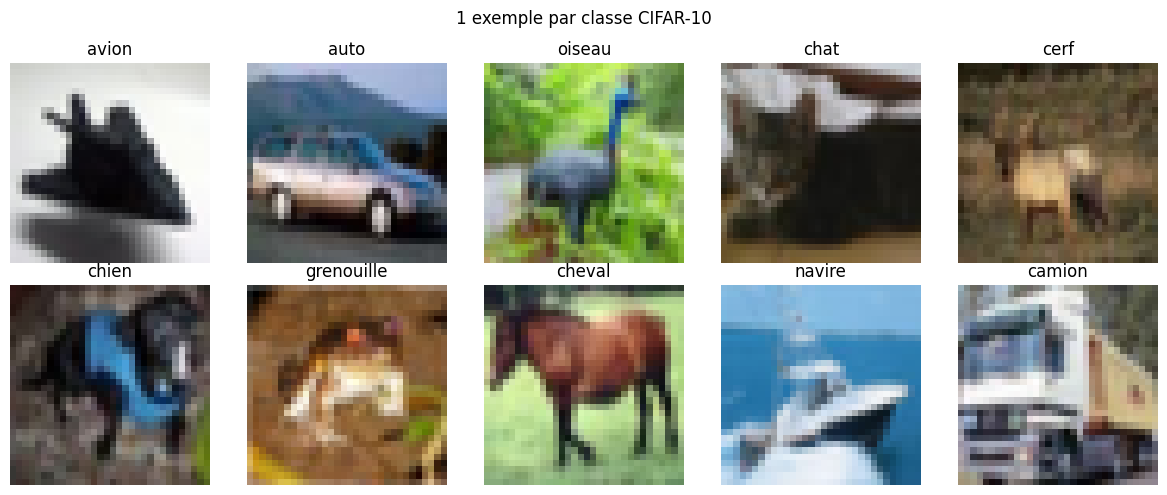

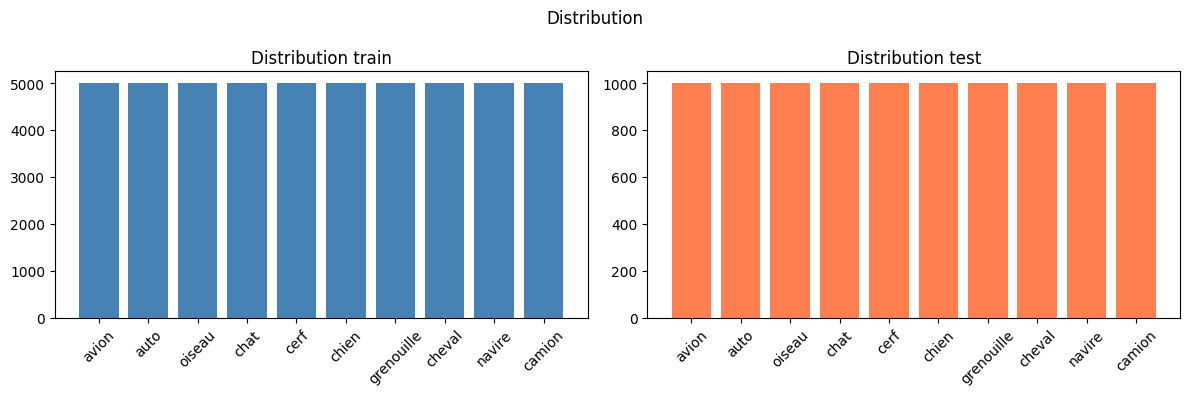

In [ ]:
import os
import sys
import gc

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_CPP_MIN_VLOG_LEVEL"] = "0"       
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=0"

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)    # suppress absl INFO/WARNING

import tensorflow as tf
tf.get_logger().setLevel('ERROR')                  # suppress TF Python-level logs

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

from tensorflow import keras
from tensorflow.keras import layers, applications


sys.path.insert(0, "Devoir partie 2/code")
from visualization import (
    image_sample_by_class,
    distribution,
    confusion_matrices,
    classification_error_samples,
    error_confidence,
    learning_curve
    )


print(sys.executable)
# sys.executable = "./scripts/tf_gpu_env.fish
print("LD_LIBRARY_PATH contains nvidia:", "site-packages/nvidia" in os.environ.get("LD_LIBRARY_PATH",""))

USE_GPU = True
CLASS_NAMES = ['avion','auto','oiseau','chat','cerf',
               'chien','grenouille','cheval','navire','camion']
               
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
if gpus and USE_GPU:
    tf.config.set_visible_devices(gpus[0], "GPU")

    # Set memory growth If you want to use the local GPU IN case of desktop performance issues
    # tf.config.experimental.set_memory_growth(gpus[0], True)
    
else:
    print("No GPU detected by TensorFlow. CPU fallback.")

# Notebook  : Réseaux de Neurones Convolutionnels (CNN) pour la Classification d’Images
# Charger le dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalisation des images
x_train, x_test = x_train / 255.0, x_test / 255.0

# Exemples d'images CIFAR-10 par classe
image_sample_by_class(x_train, y_train)
# Distribution des classes (train + test)
distribution(y_train, y_test)


I0000 00:00:1775870985.866544    3771 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1775870985.873066    3771 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1775870985.874993    3771 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1775870985.977975    3771 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Epoch 1/100


W0000 00:00:1775870987.600483    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870987.610375    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870987.610486    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870987.612087    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870987.612240    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870987.612365    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870987.619197    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870987.619299    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870987.619766    3918 gp

   4/1563 [..............................] - ETA: 34s - loss: 2.3104 - accuracy: 0.1094  

W0000 00:00:1775870988.227921    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870988.228205    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870988.228313    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870988.229334    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870988.229418    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870988.229502    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870988.229585    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870988.229694    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775870988.229817    3917 gp

...

1563/1563 [==============================] - 3s 2ms/step - loss: 0.6938 - accuracy: 0.7567 - val_loss: 0.8437 - val_accuracy: 0.7048
Epoch 7/100
1557/1563 [============================>.] - ETA: 0s - loss: 0.6337 - accuracy: 0.7761

W0000 00:00:1775871012.480100    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871012.480208    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871012.480256    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871012.480290    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871012.480333    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871012.480372    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871012.480418    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871012.480478    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871012.480536    3917 gp

1563/1563 [==============================] - 4s 2ms/step - loss: 0.6340 - accuracy: 0.7760 - val_loss: 0.8603 - val_accuracy: 0.7093
Epoch 8/100
1550/1563 [============================>.] - ETA: 0s - loss: 0.5878 - accuracy: 0.7934

W0000 00:00:1775871015.946714    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871015.946822    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871015.946881    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871015.946923    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871015.946956    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871015.946991    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871015.947042    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871015.947097    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871015.947154    3910 gp

1563/1563 [==============================] - 3s 2ms/step - loss: 0.5881 - accuracy: 0.7934 - val_loss: 0.9331 - val_accuracy: 0.6968
Epoch 9/100
1563/1563 [==============================] - 4s 2ms/step - loss: 0.5410 - accuracy: 0.8087 - val_loss: 0.8784 - val_accuracy: 0.7120
Epoch 10/100
1563/1563 [==============================] - 3s 2ms/step - loss: 0.5036 - accuracy: 0.8217 - val_loss: 0.8558 - val_accuracy: 0.7235
Epoch 11/100
1563/1563 [==============================] - 3s 2ms/step - loss: 0.4578 - accuracy: 0.8379 - val_loss: 0.9420 - val_accuracy: 0.7114
Epoch 12/100
1563/1563 [==============================] - 3s 2ms/step - loss: 0.4224 - accuracy: 0.8486 - val_loss: 0.9498 - val_accuracy: 0.7206
Epoch 13/100
1563/1563 [==============================] - 4s 2ms/step - loss: 0.3863 - accuracy: 0.8618 - val_loss: 0.9780 - val_accuracy: 0.7111
Epoch 14/100
1563/1563 [==============================] - 3s 2ms/step - loss: 0.3543 - accuracy: 0.8741 - val_loss: 1.0376 - val_accuracy:

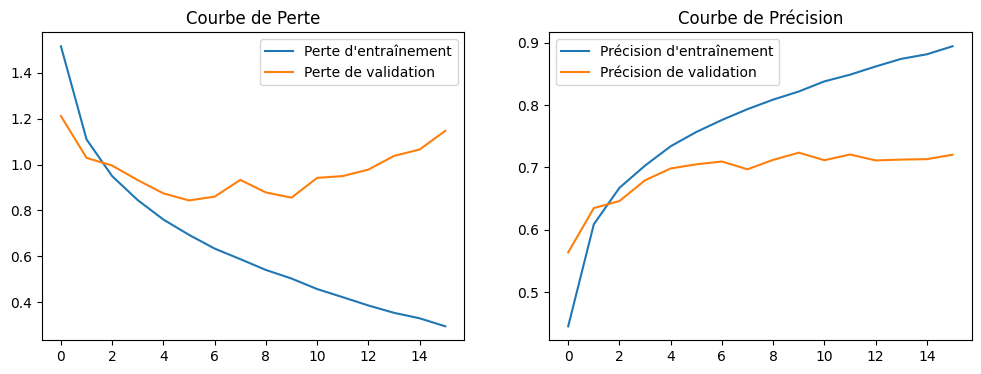

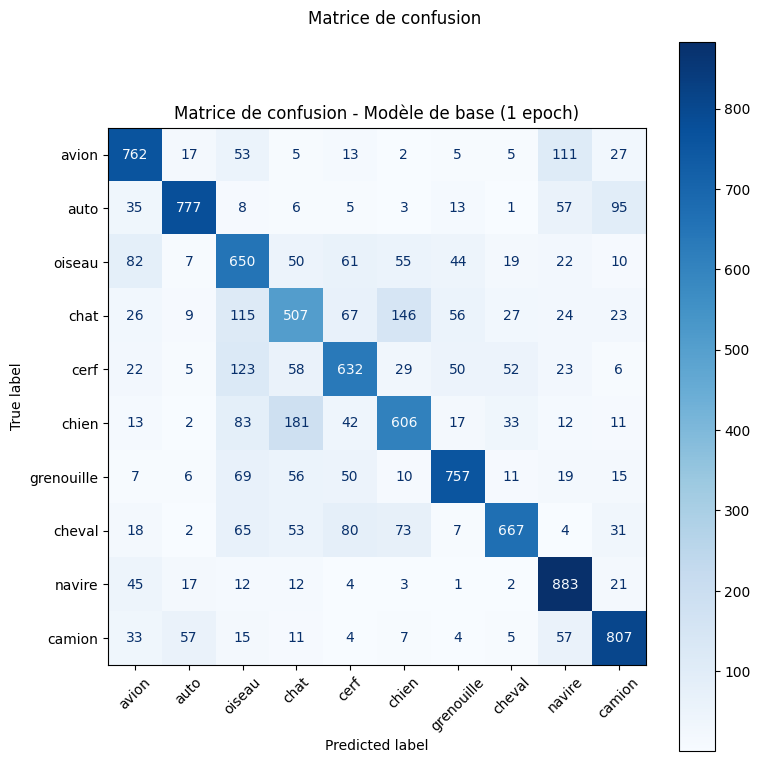

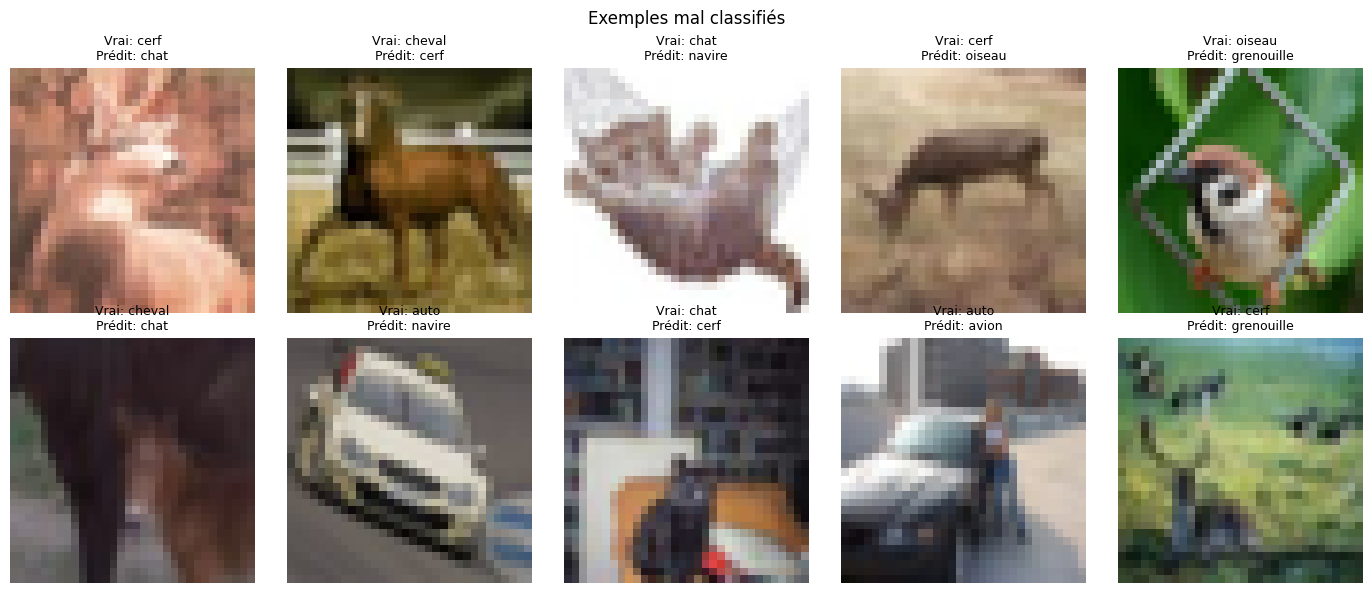

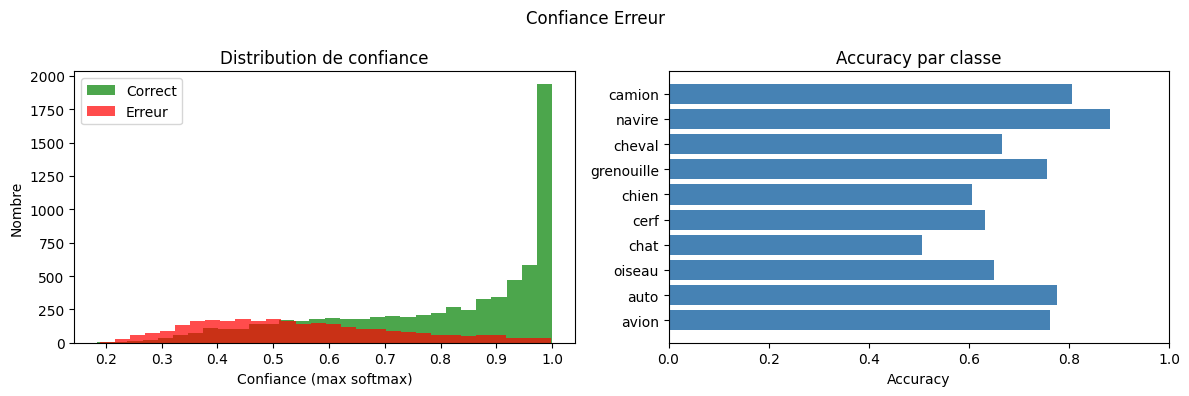

32447

In [4]:
# Définition du modèle CNN de base
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/20


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 6s 3ms/step - loss: 1.6724 - accuracy: 0.3864 - val_loss: 1.2868 - val_accuracy: 0.5362
Epoch 2/20
1563/1563 [==============================] - 5s 3ms/step - loss: 1.3467 - accuracy: 0.5173 - val_loss: 1.1998 - val_accuracy: 0.5648
Epoch 3/20
1563/1563 [==============================] - 5s 3ms/step - loss: 1.2177 - accuracy: 0.5682 - val_loss: 1.0996 - val_accuracy: 0.6010
Epoch 4/20
1563/1563 [==============================] - 5s 3ms/step - loss: 1.1268 - accuracy: 0.6077 - val_loss: 1.0412 - val_accuracy: 0.6261
Epoch 5/20
1563/1563 [==============================] - 5s 3ms/step - loss: 1.0740 - accuracy: 0.6263 - val_loss: 1.0945 - val_accuracy: 0.6273
Epoch 6/20
1563/1563 [==============================] - 5s 3ms/step - loss: 1.0258 - accuracy: 0.6460 - val_loss: 0.8743 - val_accuracy: 0.7071
Epoch 7/20
1563/1563 [==============================] - 5s 3ms/step - loss: 0.9901 - accuracy: 0.6603 - val_loss: 0.8584 - val_accuracy: 0.7094
Epo

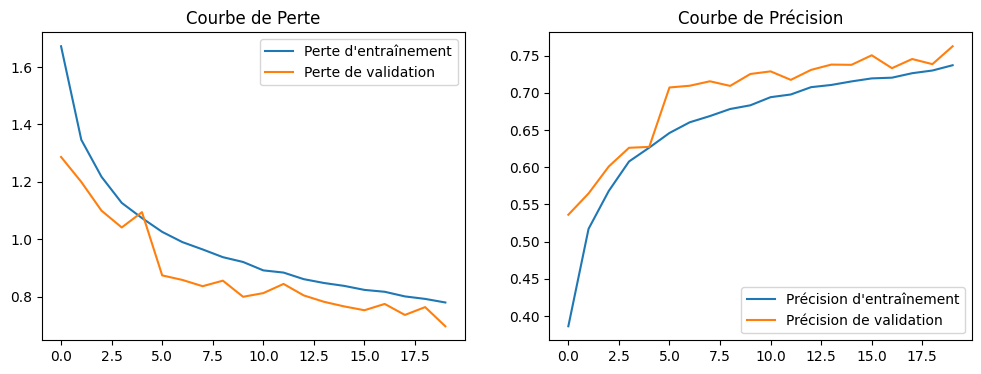

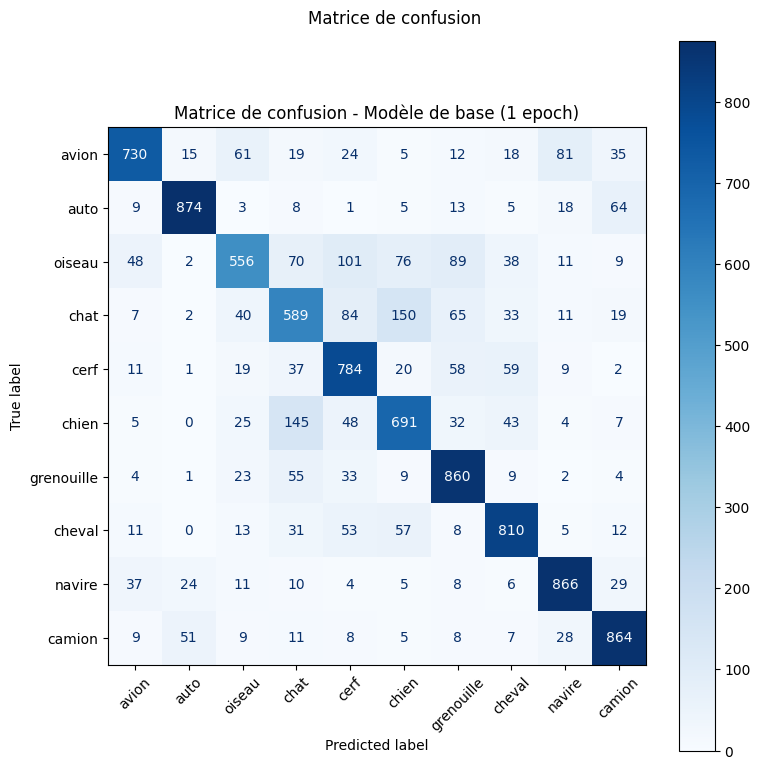

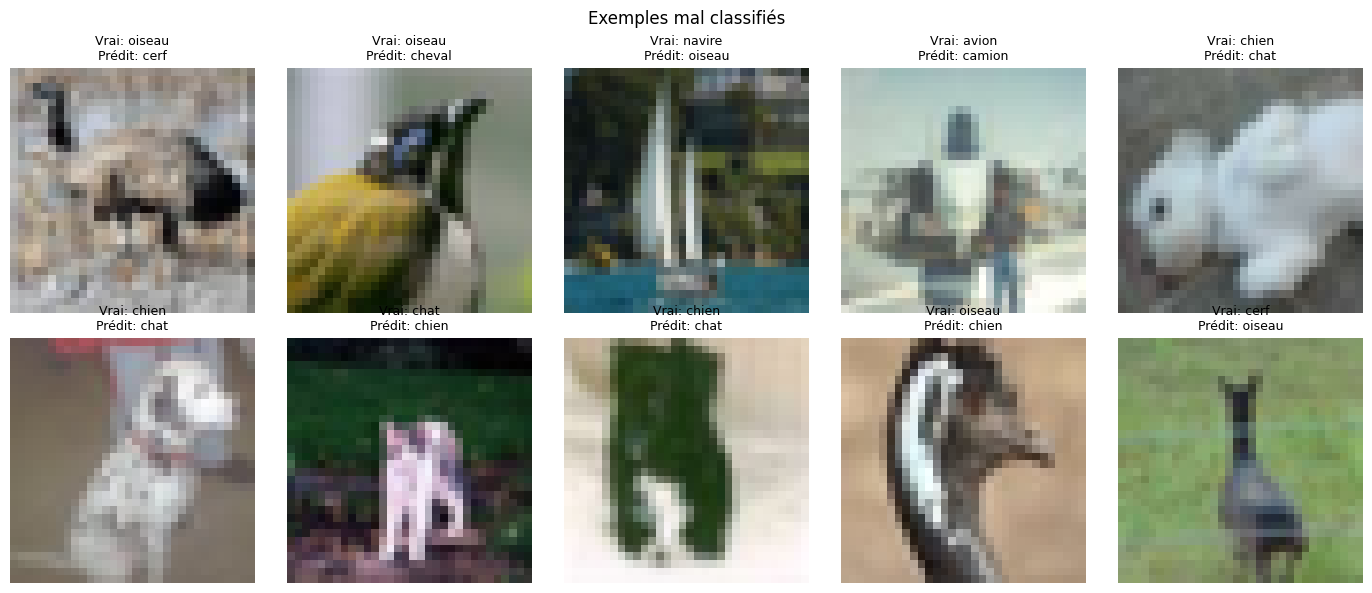

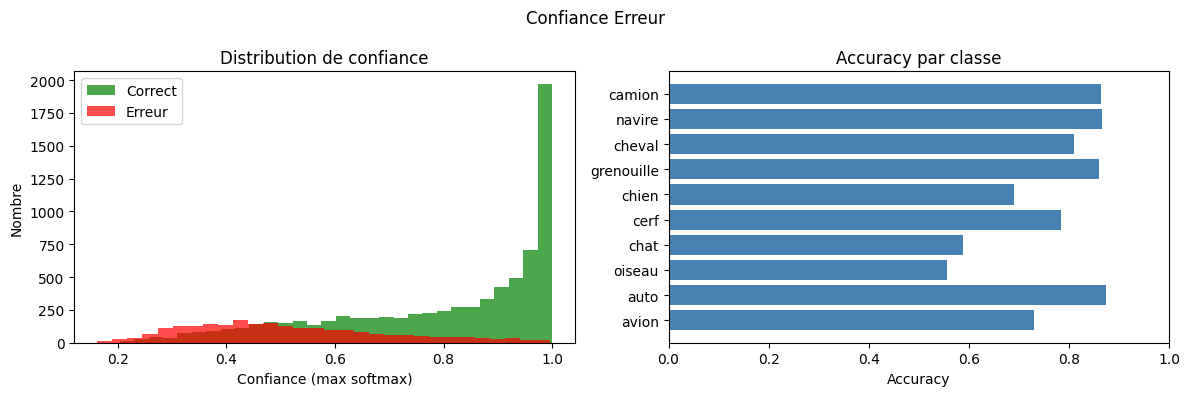

77703

In [15]:
# Définition du modèle CNN
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25), #Ajout
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25), #Ajout
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), #Ajout
    layers.Dropout(0.5), #Ajout
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100


W0000 00:00:1775871048.179671    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.179773    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.179810    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.179841    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.179881    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.179925    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.179977    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.180013    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.180048    3918 gp

  52/1563 [..............................] - ETA: 4s - loss: 2.1438 - accuracy: 0.2704

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1775871048.622268    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.622348    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.622385    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.622419    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.622451    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.622480    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871048.622548    3917 gpu_timer.cc:114] Skipping

1544/1563 [============================>.] - ETA: 0s - loss: 1.2959 - accuracy: 0.5434

...

1563/1563 [==============================] - 5s 3ms/step - loss: 1.2914 - accuracy: 0.5449 - val_loss: 1.3653 - val_accuracy: 0.5501
Epoch 2/100
  68/1563 [>.............................] - ETA: 3s - loss: 0.9726 - accuracy: 0.6489

W0000 00:00:1775871052.946729    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871052.946842    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871052.946874    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871052.946915    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871052.946943    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871052.946984    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871052.947007    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871052.947055    3918 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871052.947112    3918 gp

1547/1563 [============================>.] - ETA: 0s - loss: 0.9281 - accuracy: 0.6720

W0000 00:00:1775871056.175644    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871056.175806    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871056.175838    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871056.175920    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871056.175969    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871056.176018    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871056.176140    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871056.176190    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871056.176256    3916 gp

1563/1563 [==============================] - 4s 2ms/step - loss: 0.9274 - accuracy: 0.6725 - val_loss: 0.9904 - val_accuracy: 0.6504
Epoch 3/100
1563/1563 [==============================] - 4s 2ms/step - loss: 0.7743 - accuracy: 0.7279 - val_loss: 1.1479 - val_accuracy: 0.6214
Epoch 4/100
1563/1563 [==============================] - 4s 3ms/step - loss: 0.6618 - accuracy: 0.7691 - val_loss: 0.8818 - val_accuracy: 0.7024
Epoch 5/100
1563/1563 [==============================] - 4s 2ms/step - loss: 0.5780 - accuracy: 0.7971 - val_loss: 0.9097 - val_accuracy: 0.6980
Epoch 6/100
1563/1563 [==============================] - 4s 2ms/step - loss: 0.5019 - accuracy: 0.8237 - val_loss: 1.2175 - val_accuracy: 0.6320
Epoch 7/100
1563/1563 [==============================] - 4s 3ms/step - loss: 0.4352 - accuracy: 0.8471 - val_loss: 0.9482 - val_accuracy: 0.7059
Epoch 8/100
1563/1563 [==============================] - 4s 2ms/step - loss: 0.3801 - accuracy: 0.8661 - val_loss: 0.9396 - val_accuracy: 0.72

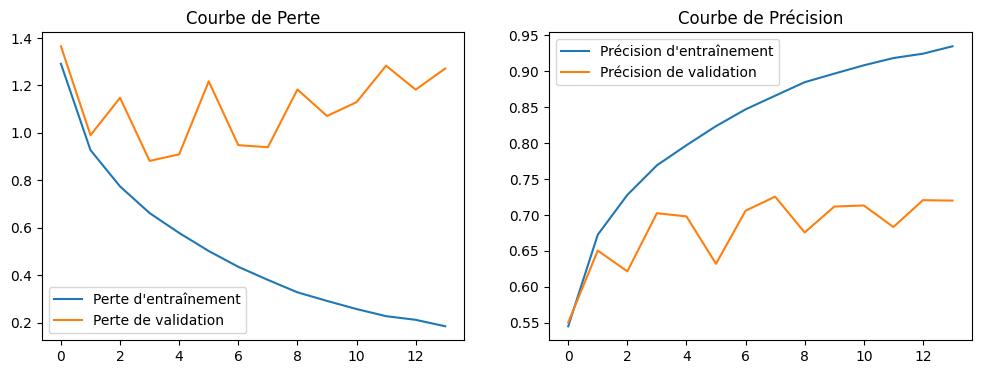

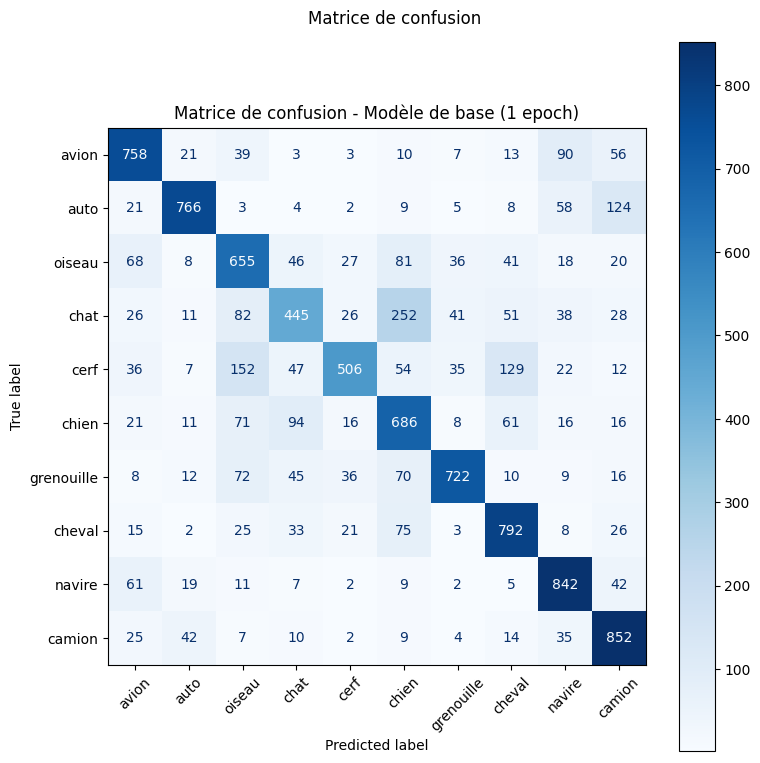

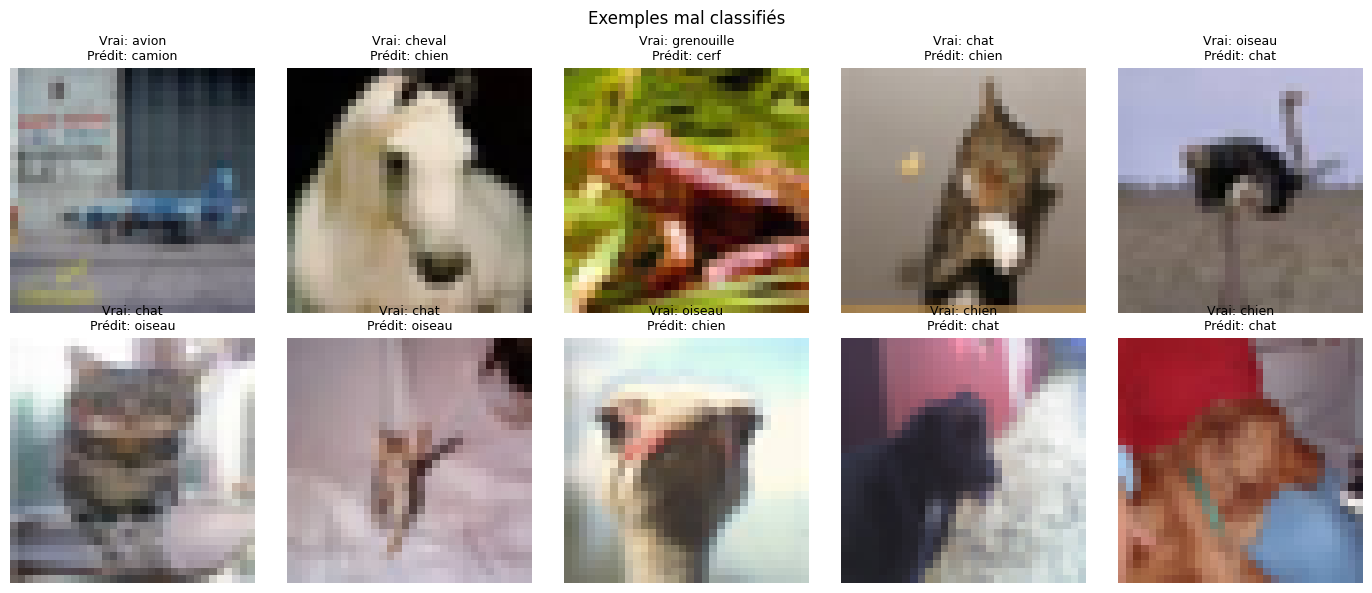

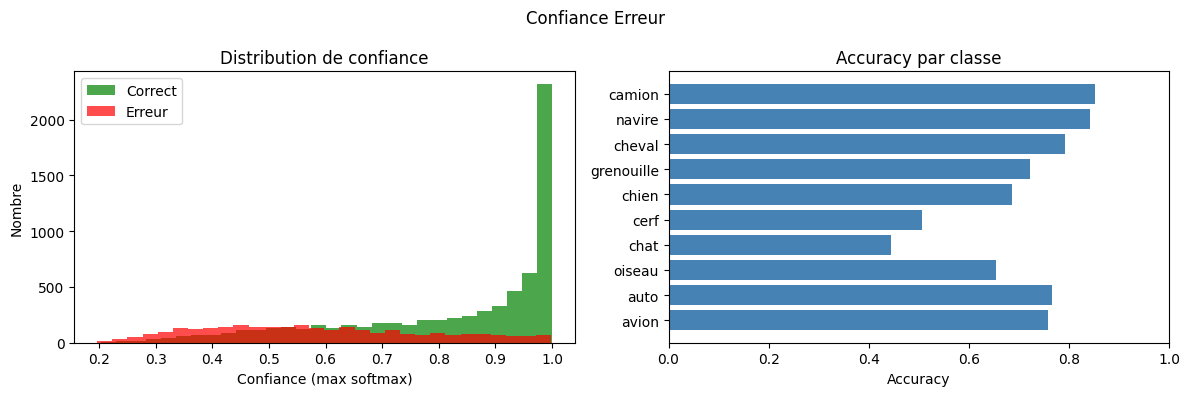

65513

In [5]:
# Définition du modèle CNN avec BatchNormalisation(use_bias=False)
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), use_bias=False, activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), use_bias=False, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), use_bias=False, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  10/1563 [..............................] - ETA: 8s - loss: 4.5808 - accuracy: 0.1250   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1775871107.795908    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871107.795975    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871107.796010    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871107.796059    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871107.796092    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871107.796130    3910 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871107.796170    3910 gpu_timer.cc:114] Skipping

1553/1563 [============================>.] - ETA: 0s - loss: 1.8618 - accuracy: 0.3262

...

1563/1563 [==============================] - 6s 3ms/step - loss: 1.8604 - accuracy: 0.3267 - val_loss: 1.4571 - val_accuracy: 0.4709
Epoch 2/100
1552/1563 [============================>.] - ETA: 0s - loss: 1.4897 - accuracy: 0.4613

W0000 00:00:1775871116.435502    3914 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871116.435607    3914 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871116.435645    3914 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871116.435681    3914 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871116.435731    3914 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871116.435780    3914 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871116.435836    3914 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871116.435871    3914 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871116.435952    3914 gp

1563/1563 [==============================] - 4s 3ms/step - loss: 1.4892 - accuracy: 0.4615 - val_loss: 1.5318 - val_accuracy: 0.4523
Epoch 3/100
1551/1563 [============================>.] - ETA: 0s - loss: 1.3426 - accuracy: 0.5214

W0000 00:00:1775871120.754814    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871120.754888    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871120.754925    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871120.754960    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871120.755007    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871120.755046    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871120.755096    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871120.755130    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775871120.755213    3908 gp

1563/1563 [==============================] - 4s 3ms/step - loss: 1.3423 - accuracy: 0.5216 - val_loss: 1.1513 - val_accuracy: 0.5898
Epoch 4/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.2614 - accuracy: 0.5532 - val_loss: 1.1498 - val_accuracy: 0.5909
Epoch 5/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.1891 - accuracy: 0.5785 - val_loss: 1.0484 - val_accuracy: 0.6254
Epoch 6/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.1360 - accuracy: 0.6029 - val_loss: 1.1717 - val_accuracy: 0.6035
Epoch 7/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.0987 - accuracy: 0.6178 - val_loss: 0.9711 - val_accuracy: 0.6586
Epoch 8/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.0601 - accuracy: 0.6311 - val_loss: 1.3177 - val_accuracy: 0.5796
Epoch 9/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.0358 - accuracy: 0.6400 - val_loss: 0.9006 - val_accuracy: 0.69

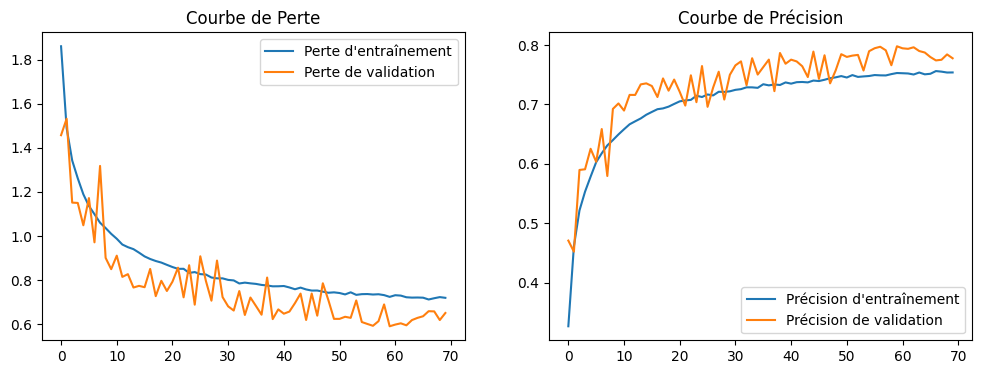

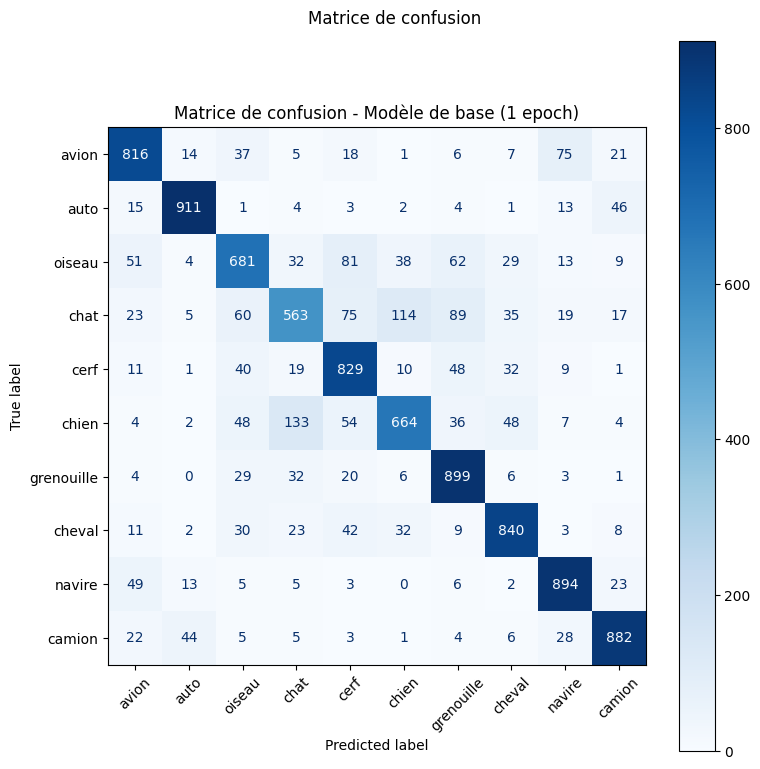

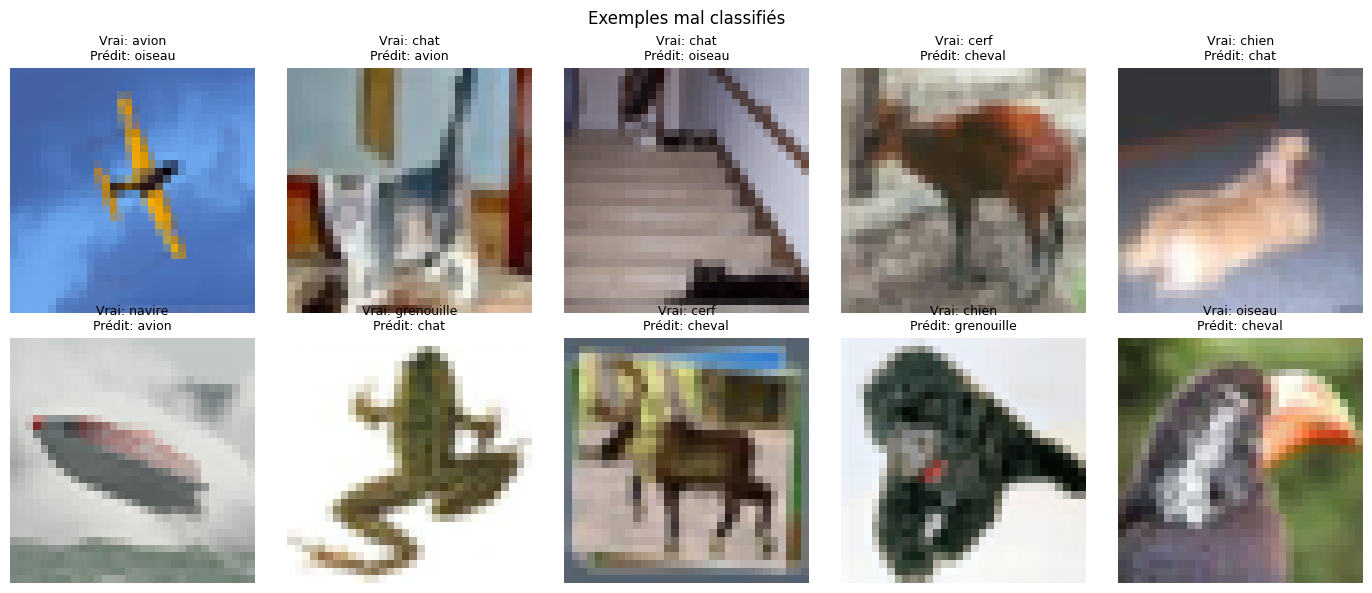

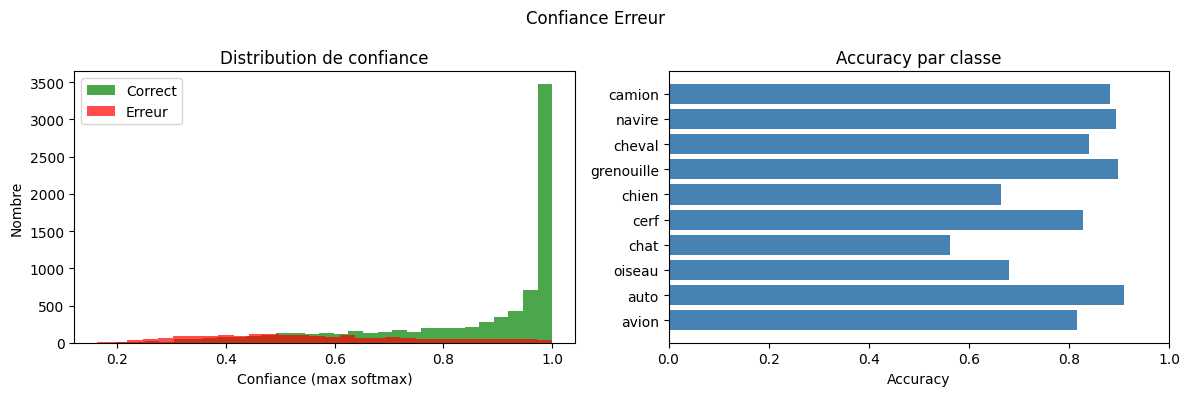

67392

In [6]:
# Définition du modèle CNN avec BatchNormalisation(use_bias=False), Dropout(0.25, 0.5)
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), use_bias=False, activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), use_bias=False, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), use_bias=False, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  65/1563 [>.............................] - ETA: 3s - loss: 3.1660 - accuracy: 0.1740

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1563/1563 [==============================] - 6s 3ms/step - loss: 1.8018 - accuracy: 0.3799 - val_loss: 1.3276 - val_accuracy: 0.5224
Epoch 2/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.3476 - accuracy: 0.5158 - val_loss: 1.4523 - val_accuracy: 0.4652
Epoch 3/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.2132 - accuracy: 0.5700 - val_loss: 1.0747 - val_accuracy: 0.6117
Epoch 4/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.1391 - accuracy: 0.6000 - val_loss: 1.1218 - val_accuracy: 0.6010
Epoch 5/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.0840 - accuracy: 0.6189 - val_loss: 0.9061 - val_accuracy: 0.6798
Epoch 6/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.0427 - accuracy: 0.6329 - val_loss: 0.9205 - val_accuracy: 0.6801
Epoch 7/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.0172 - accuracy: 0.6454 - val_loss: 0.8802 - val_accuracy: 0.68

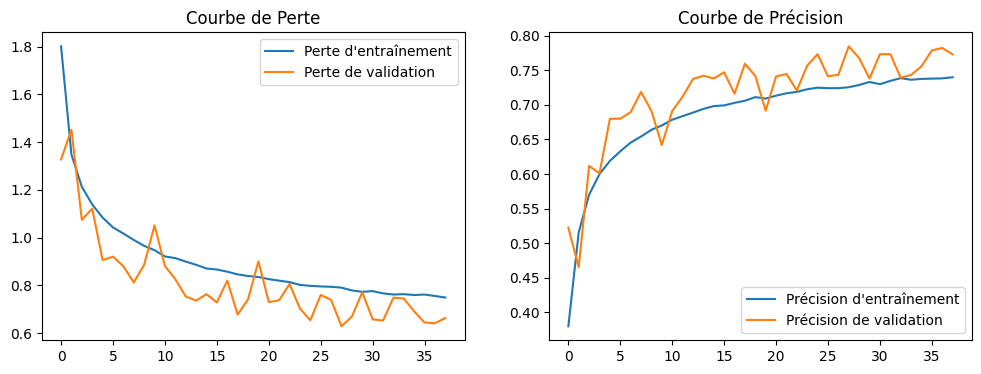

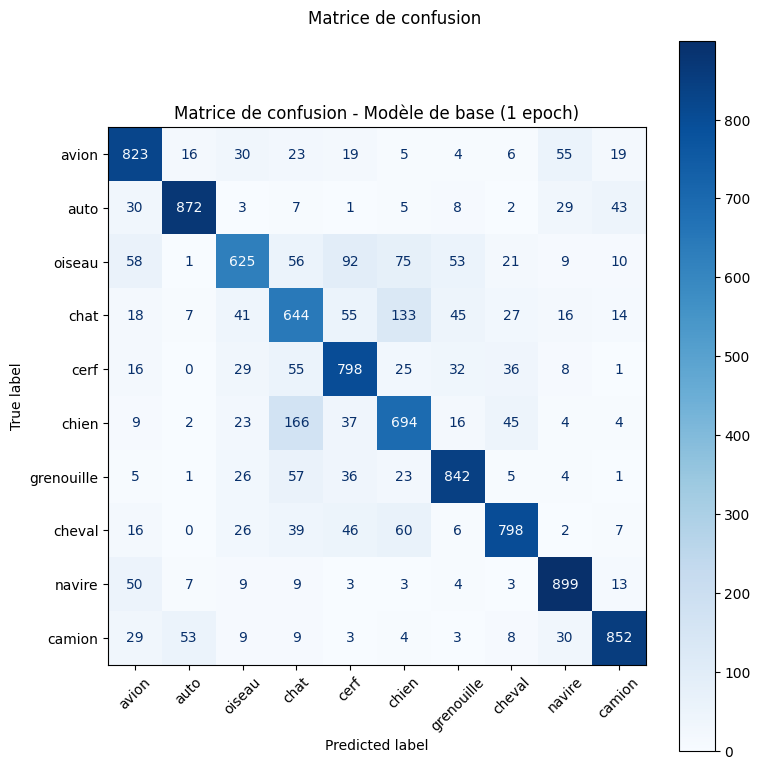

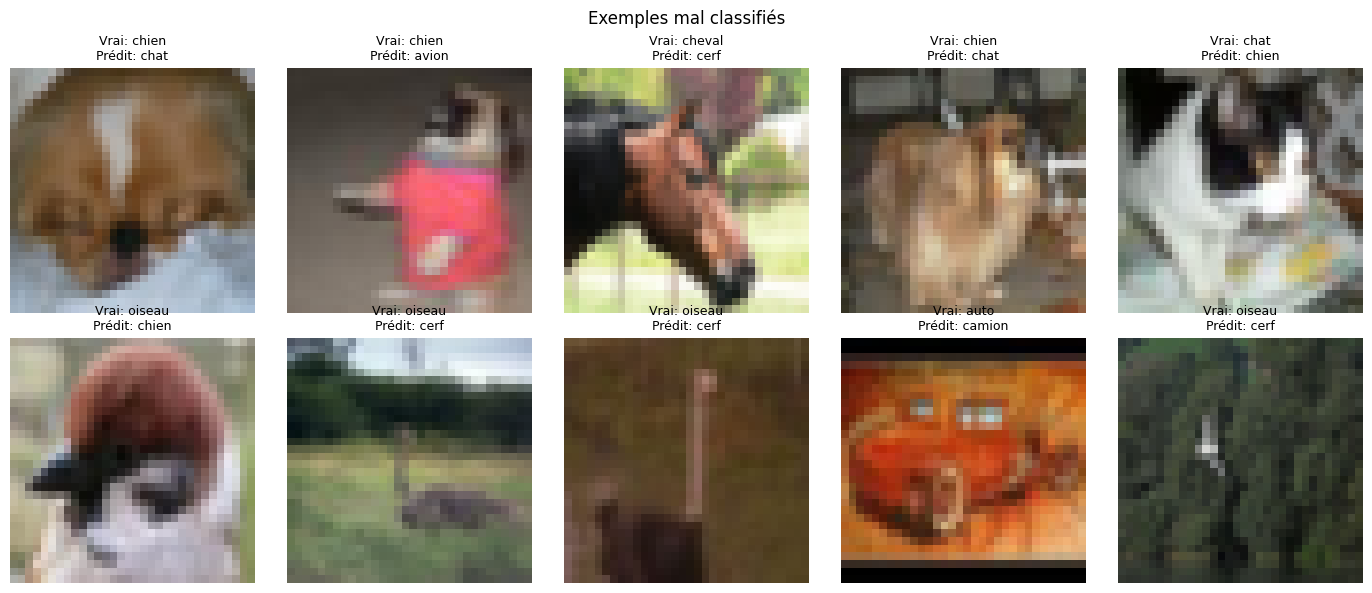

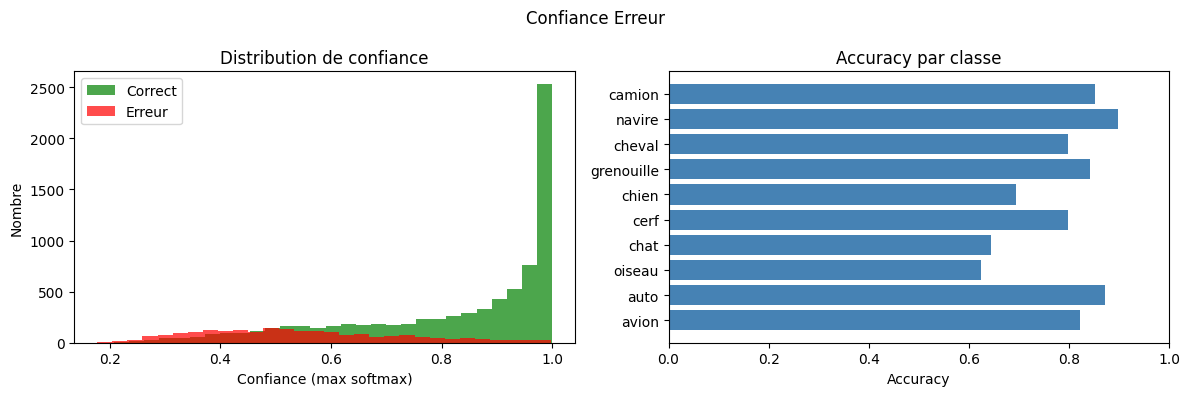

70383

In [7]:
# Définition du modèle CNN avec BatchNormalisation(use_bias=False), Dropout(0.25, 0.5), activation="elu"
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), use_bias=False, activation='elu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), use_bias=False, activation='elu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), use_bias=False, activation='elu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='elu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  58/1563 [>.............................] - ETA: 4s - loss: 3.0912 - accuracy: 0.1439

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1563/1563 [==============================] - 6s 3ms/step - loss: 1.8308 - accuracy: 0.3466 - val_loss: 2.0388 - val_accuracy: 0.3426
Epoch 2/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.4404 - accuracy: 0.4840 - val_loss: 1.3427 - val_accuracy: 0.5278
Epoch 3/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.2932 - accuracy: 0.5429 - val_loss: 1.2125 - val_accuracy: 0.5847
Epoch 4/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.1969 - accuracy: 0.5800 - val_loss: 1.0679 - val_accuracy: 0.6161
Epoch 5/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.1382 - accuracy: 0.6033 - val_loss: 1.2261 - val_accuracy: 0.5844
Epoch 6/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.0915 - accuracy: 0.6184 - val_loss: 0.9692 - val_accuracy: 0.6563
Epoch 7/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.0487 - accuracy: 0.6371 - val_loss: 1.0759 - val_accuracy: 0.62

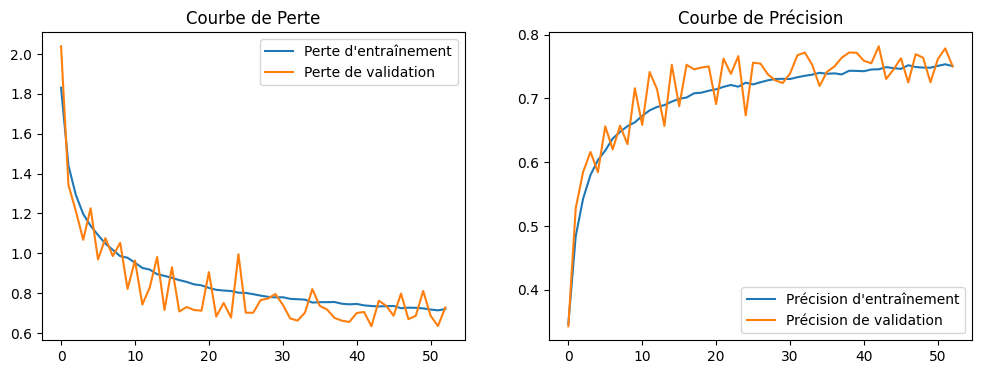

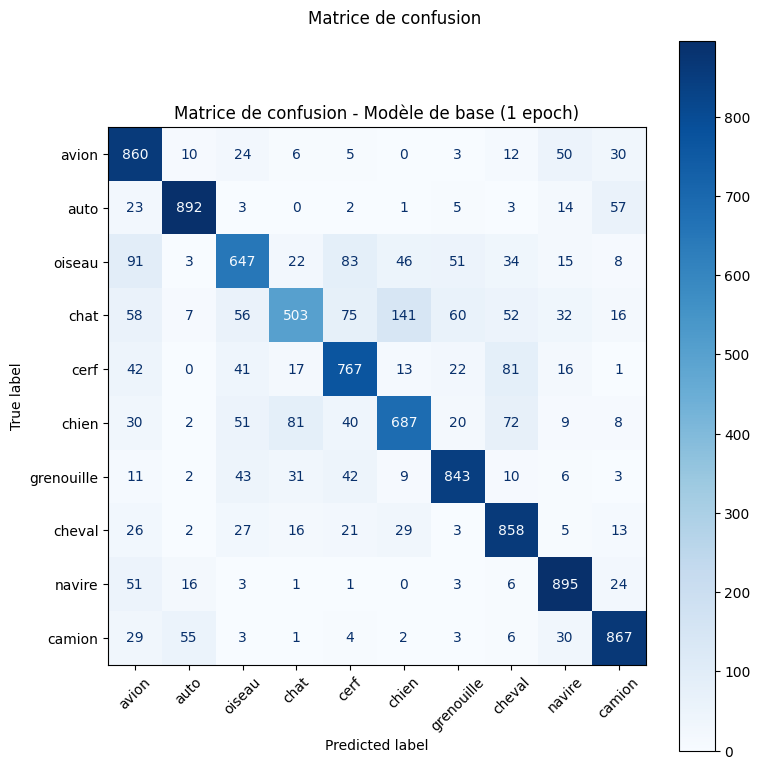

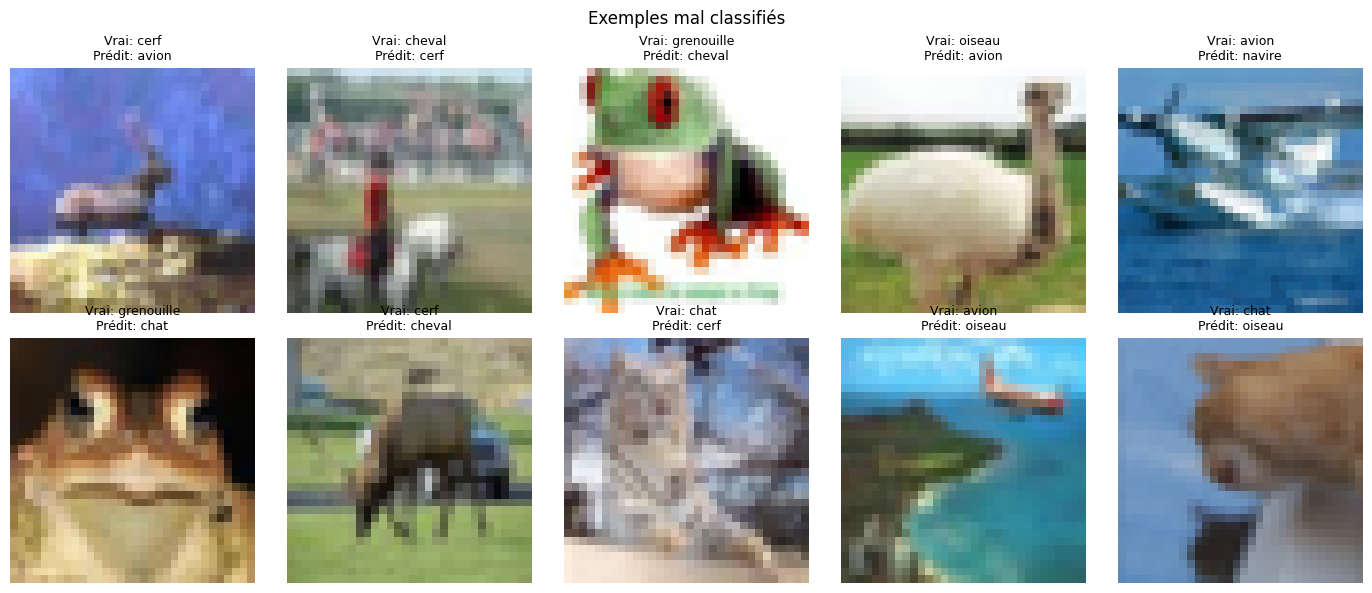

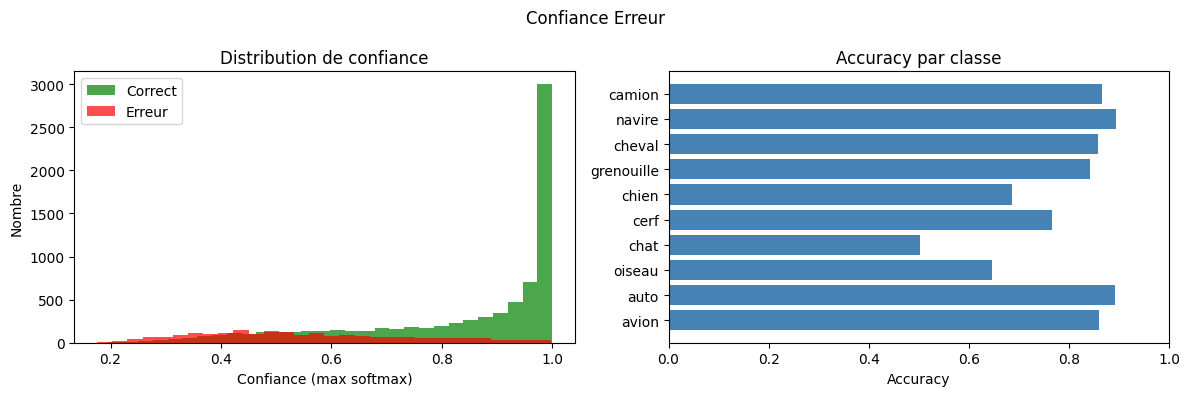

70430

In [8]:
# Définition du modèle CNN avec 
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish"

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100
   1/1563 [..............................] - ETA: 21:26 - loss: 6.2153 - accuracy: 0.0938

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 5s 3ms/step - loss: 1.8608 - accuracy: 0.3244 - val_loss: 1.6418 - val_accuracy: 0.4219
Epoch 2/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.5362 - accuracy: 0.4488 - val_loss: 1.2447 - val_accuracy: 0.5498
Epoch 3/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.3601 - accuracy: 0.5149 - val_loss: 1.2180 - val_accuracy: 0.5571
Epoch 4/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.2560 - accuracy: 0.5533 - val_loss: 1.3650 - val_accuracy: 0.4995
Epoch 5/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.1847 - accuracy: 0.5825 - val_loss: 1.0628 - val_accuracy: 0.6246
Epoch 6/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.1299 - accuracy: 0.6007 - val_loss: 1.2833 - val_accuracy: 0.5761
Epoch 7/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.0937 - accuracy: 0.6158 - val_loss: 0.9506 - val_accuracy: 0.66

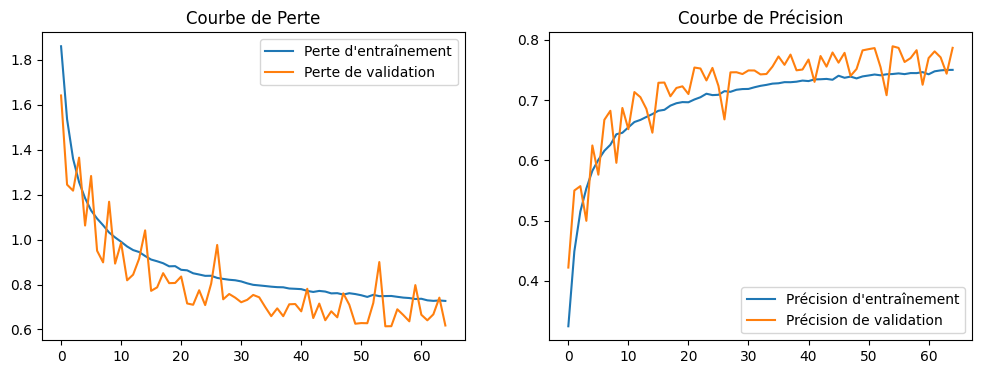

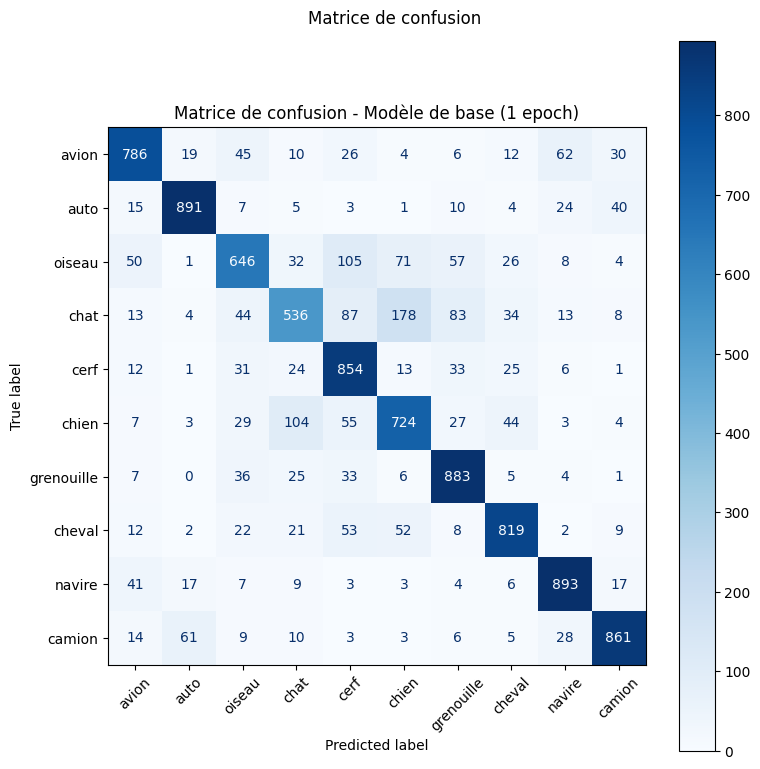

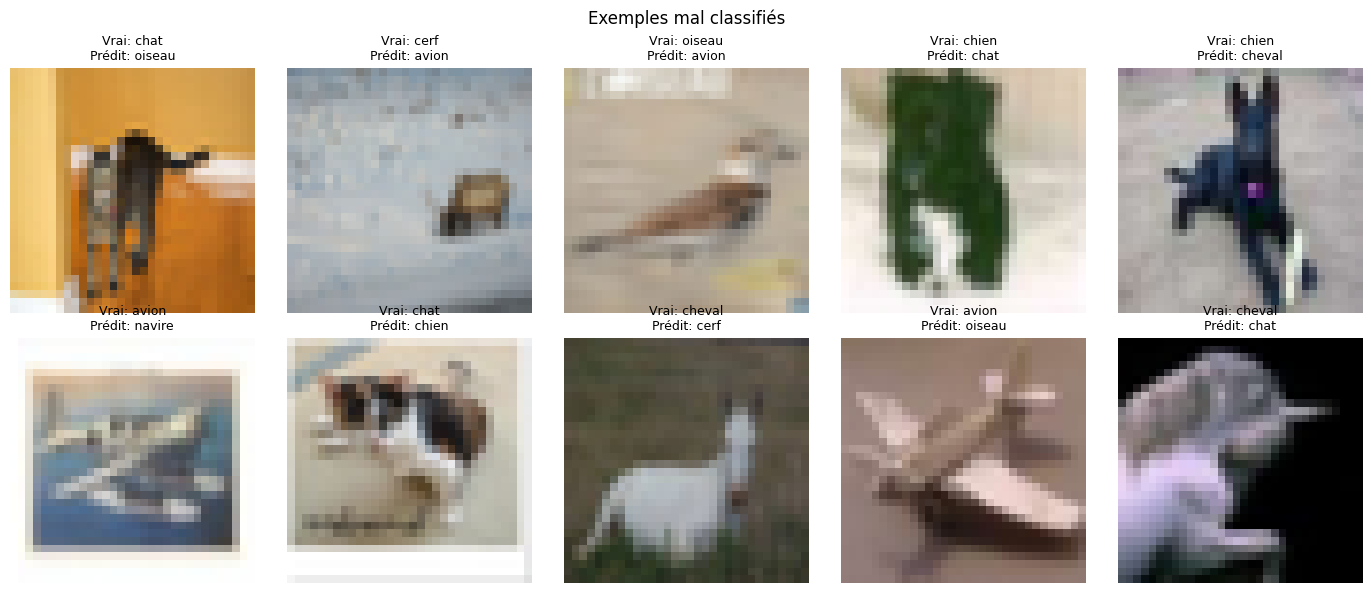

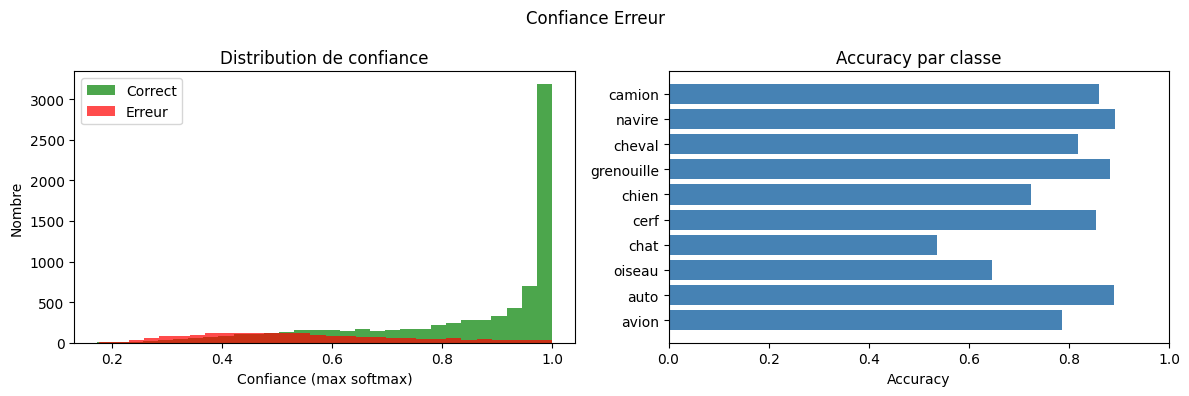

70416

In [9]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100
   1/1563 [..............................] - ETA: 22:34 - loss: 6.0288 - accuracy: 0.1250

W0000 00:00:1775872098.914584    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872098.914682    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872098.914715    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872098.914763    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872098.914817    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872098.914860    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872098.914975    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872098.915037    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872098.915312    3916 gp

1563/1563 [==============================] - ETA: 0s - loss: 2.0470 - accuracy: 0.2508

W0000 00:00:1775872103.028892    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872103.029027    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872103.029065    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872103.029092    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872103.029126    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872103.029174    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872103.029219    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872103.029299    3917 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872103.029358    3917 gp

1563/1563 [==============================] - 6s 3ms/step - loss: 2.0470 - accuracy: 0.2508 - val_loss: 2.0584 - val_accuracy: 0.3110
Epoch 2/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.7022 - accuracy: 0.3764 - val_loss: 1.5610 - val_accuracy: 0.4381
Epoch 3/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.4901 - accuracy: 0.4616 - val_loss: 1.3496 - val_accuracy: 0.5080
Epoch 4/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.3102 - accuracy: 0.5313 - val_loss: 1.1285 - val_accuracy: 0.5977
Epoch 5/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.2113 - accuracy: 0.5730 - val_loss: 1.0372 - val_accuracy: 0.6375
Epoch 6/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.1413 - accuracy: 0.5994 - val_loss: 1.2855 - val_accuracy: 0.5410
Epoch 7/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.0871 - accuracy: 0.6222 - val_loss: 0.9401 - val_accuracy: 0.67

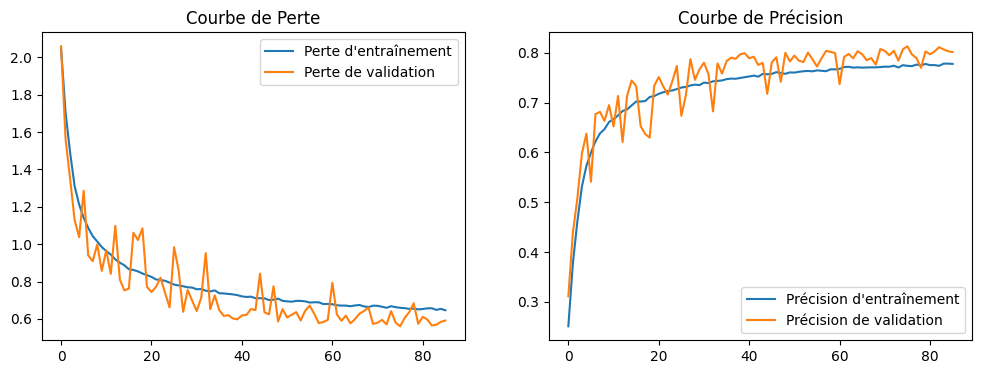

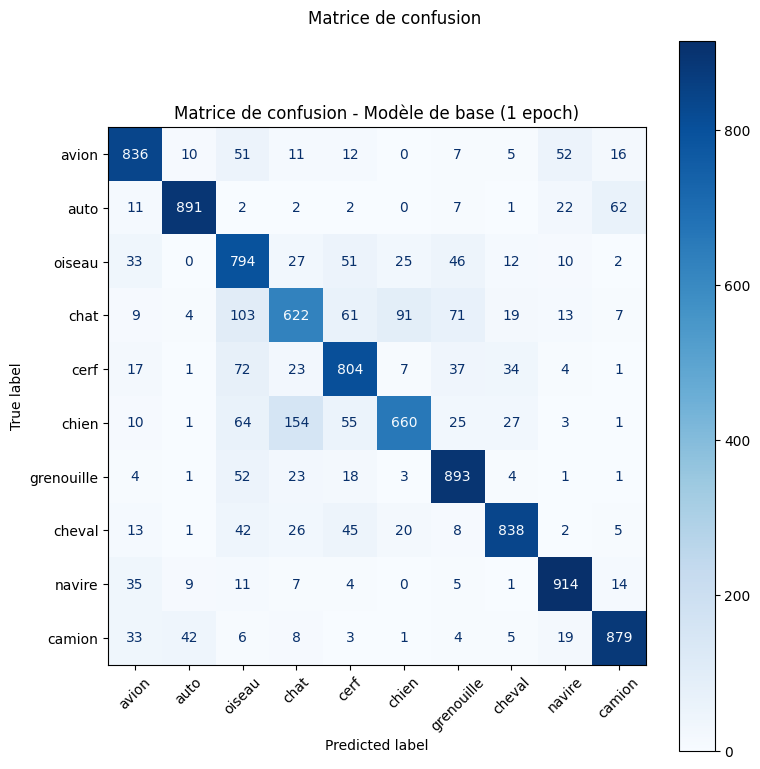

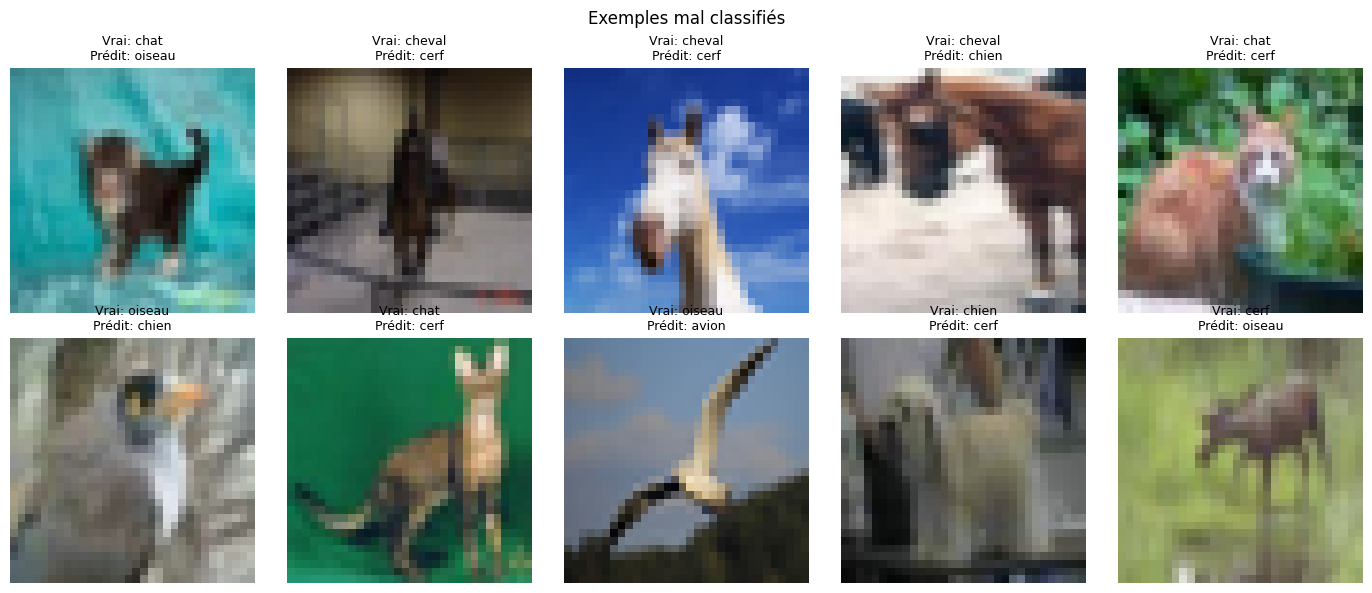

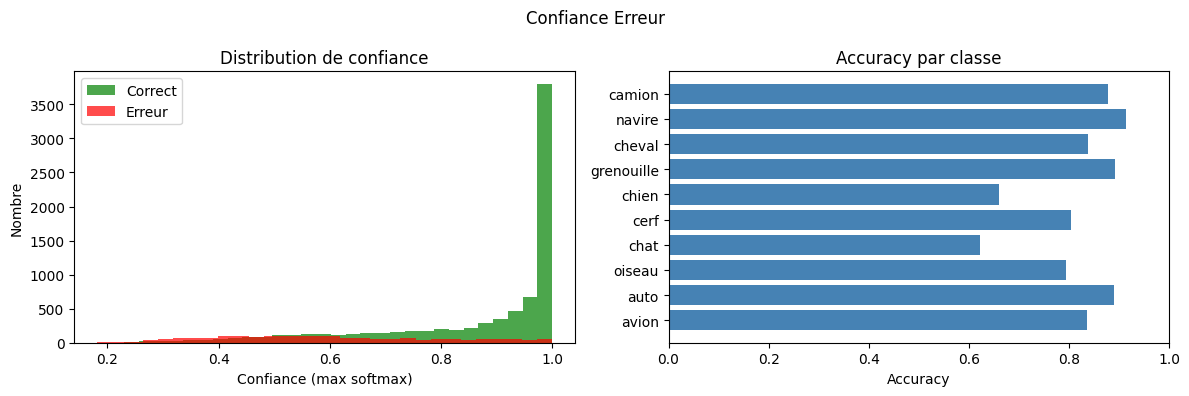

69611

In [10]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100
  20/1563 [..............................] - ETA: 4s - loss: 3.2206 - accuracy: 0.1328   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 5s 3ms/step - loss: 2.0916 - accuracy: 0.2481 - val_loss: 1.9295 - val_accuracy: 0.3058
Epoch 2/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.7572 - accuracy: 0.3797 - val_loss: 1.6589 - val_accuracy: 0.4276
Epoch 3/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.4738 - accuracy: 0.4893 - val_loss: 1.2860 - val_accuracy: 0.5477
Epoch 4/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.3065 - accuracy: 0.5510 - val_loss: 1.1063 - val_accuracy: 0.6214
Epoch 5/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.2059 - accuracy: 0.5911 - val_loss: 1.1230 - val_accuracy: 0.6293
Epoch 6/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.1402 - accuracy: 0.6149 - val_loss: 1.0389 - val_accuracy: 0.6447
Epoch 7/100
1563/1563 [==============================] - 4s 3ms/step - loss: 1.0865 - accuracy: 0.6353 - val_loss: 0.9586 - val_accuracy: 0.68

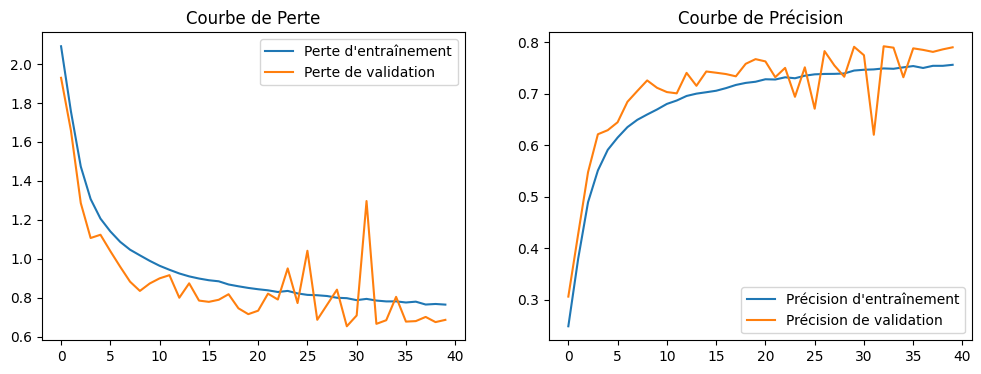

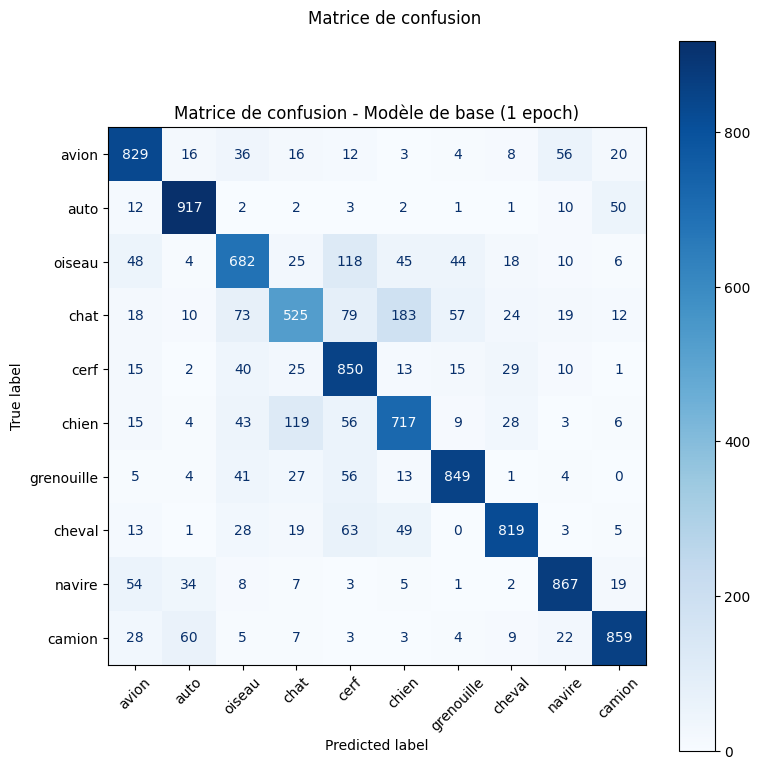

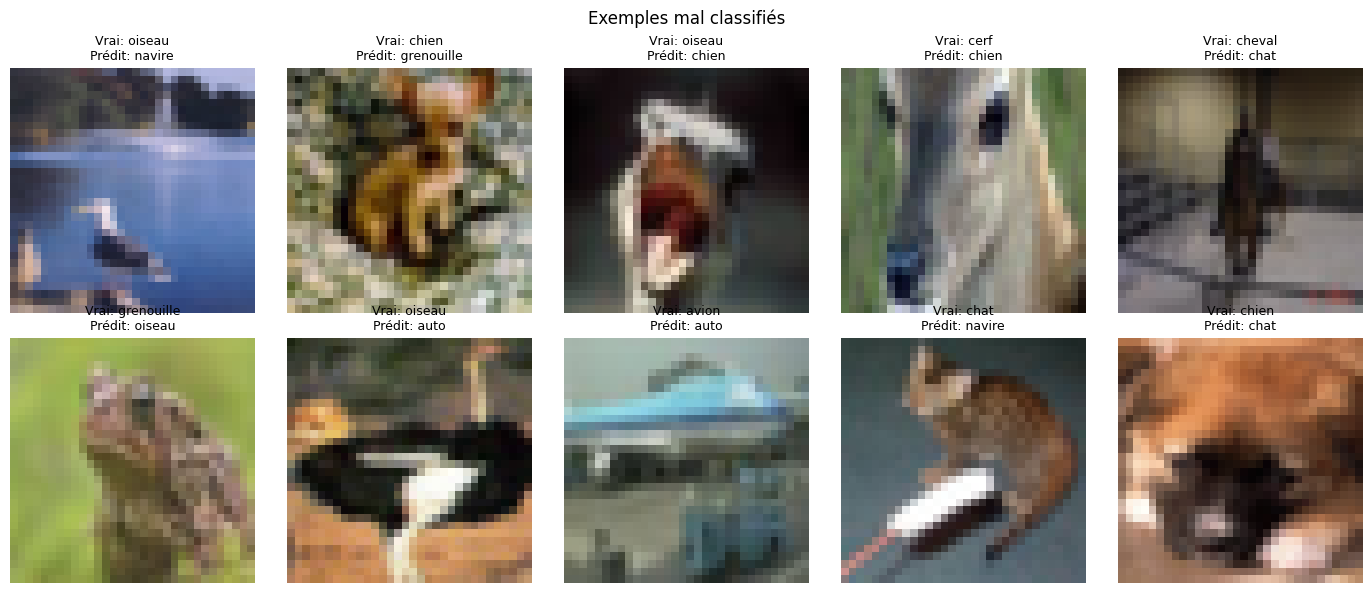

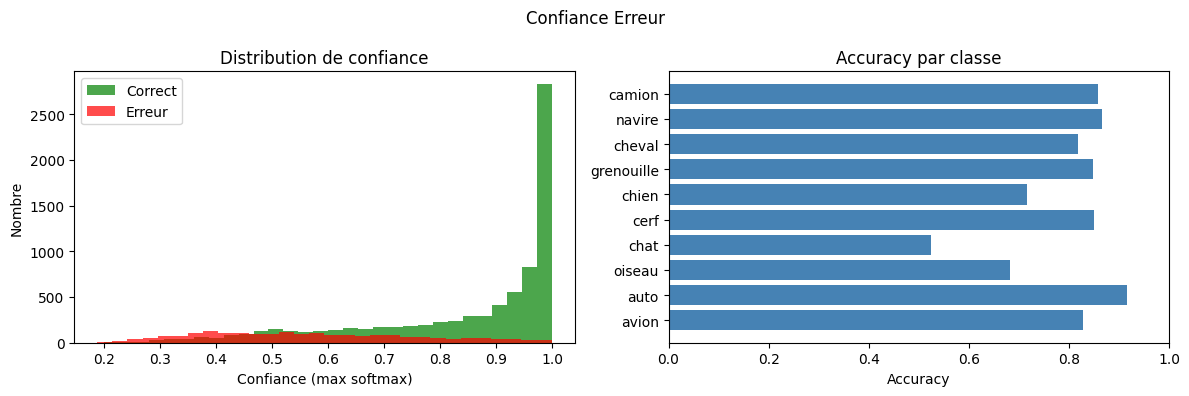

70635

In [11]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(0.01)

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='swish', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100


W0000 00:00:1775872652.820679    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872652.820791    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872652.820845    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872652.820917    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872652.820966    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872652.821004    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872652.821047    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872652.821089    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872652.821191    3916 gp

  32/1563 [..............................] - ETA: 5s - loss: 3.0048 - accuracy: 0.1475 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1775872653.049903    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872653.050057    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872653.050121    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872653.050189    3916 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872653.050234    3916 gpu_timer.cc:114] Skipping the delay kernel, measu

1561/1563 [============================>.] - ETA: 0s - loss: 1.9915 - accuracy: 0.2852

W0000 00:00:1775872657.856835    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872657.856892    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872657.856923    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872657.856952    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872657.856986    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872657.857020    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872657.857058    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872657.857093    3908 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775872657.857130    3908 gp

1563/1563 [==============================] - 7s 4ms/step - loss: 1.9914 - accuracy: 0.2852 - val_loss: 1.6152 - val_accuracy: 0.4285
Epoch 2/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.5520 - accuracy: 0.4480 - val_loss: 1.2462 - val_accuracy: 0.5746
Epoch 3/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.3224 - accuracy: 0.5453 - val_loss: 1.2509 - val_accuracy: 0.5607
Epoch 4/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.1856 - accuracy: 0.5987 - val_loss: 1.1040 - val_accuracy: 0.6304
Epoch 5/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.0813 - accuracy: 0.6390 - val_loss: 0.9105 - val_accuracy: 0.6949
Epoch 6/100
1563/1563 [==============================] - 5s 3ms/step - loss: 0.9942 - accuracy: 0.6708 - val_loss: 0.8886 - val_accuracy: 0.7065
Epoch 7/100
1563/1563 [==============================] - 5s 4ms/step - loss: 0.9237 - accuracy: 0.6959 - val_loss: 0.8238 - val_accuracy: 0.72

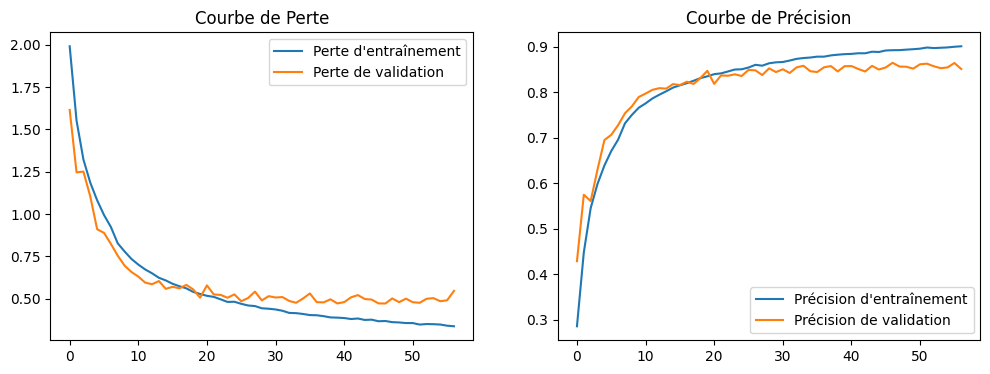

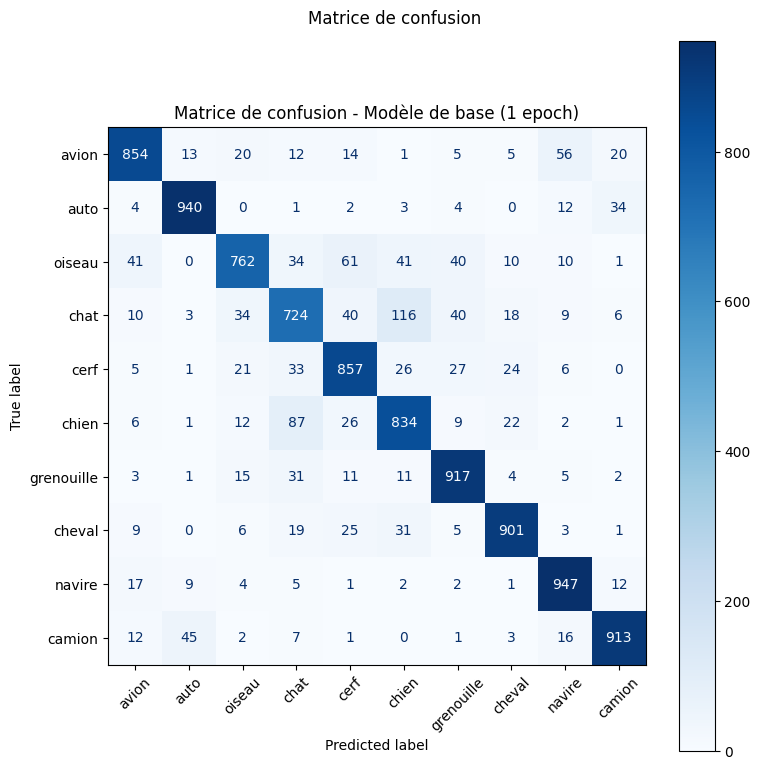

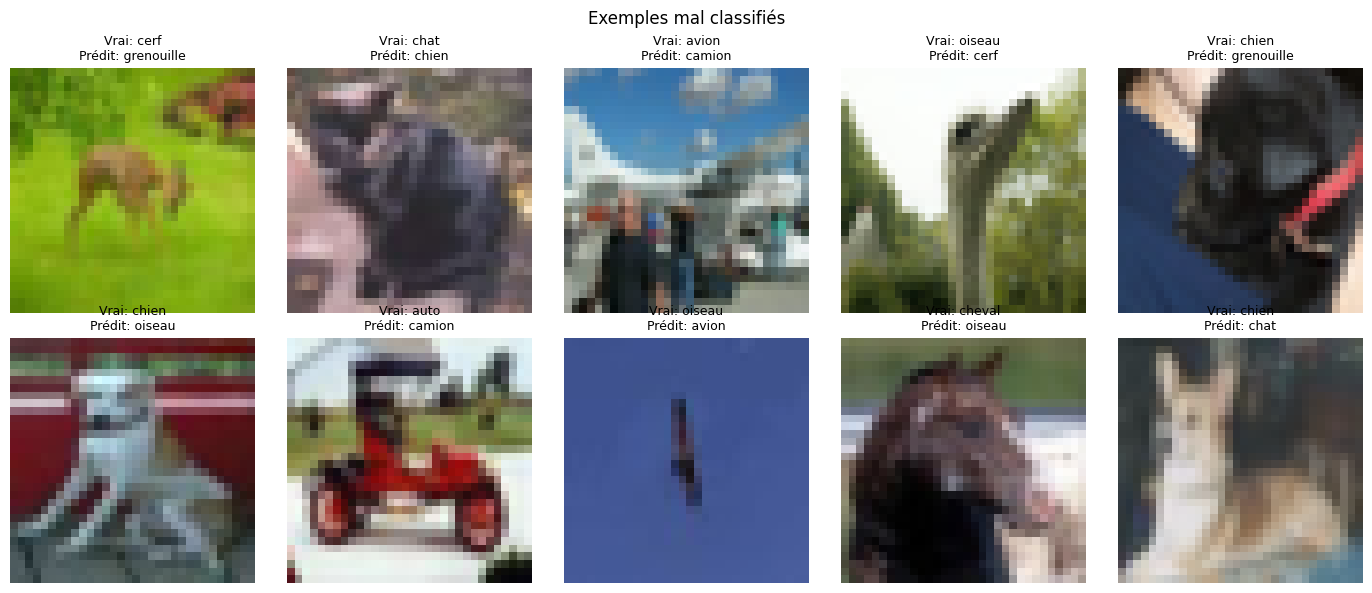

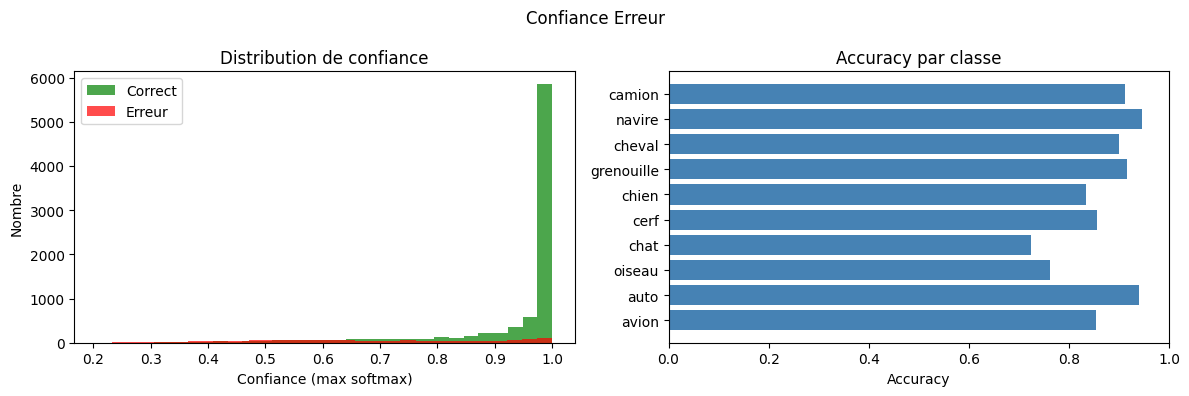

70368

In [12]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(0.01)
# - doublement de Conv2D

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='swish', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]

history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  26/1563 [..............................] - ETA: 6s - loss: 3.5900 - accuracy: 0.1502     

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

1563/1563 [==============================] - 7s 4ms/step - loss: 1.9614 - accuracy: 0.3237 - val_loss: 1.6343 - val_accuracy: 0.4375
Epoch 2/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.4459 - accuracy: 0.5045 - val_loss: 1.1595 - val_accuracy: 0.6044
Epoch 3/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.1544 - accuracy: 0.6135 - val_loss: 0.9889 - val_accuracy: 0.6751
Epoch 4/100
1563/1563 [==============================] - 6s 4ms/step - loss: 0.9977 - accuracy: 0.6711 - val_loss: 0.8453 - val_accuracy: 0.7262
Epoch 5/100
1563/1563 [==============================] - 6s 4ms/step - loss: 0.8961 - accuracy: 0.7098 - val_loss: 0.8187 - val_accuracy: 0.7331
Epoch 6/100
1563/1563 [==============================] - 5s 3ms/step - loss: 0.8208 - accuracy: 0.7365 - val_loss: 0.7592 - val_accuracy: 0.7562
Epoch 7/100
1563/1563 [==============================] - 6s 4ms/step - loss: 0.7720 - accuracy: 0.7533 - val_loss: 0.6954 - val_accuracy: 0.77

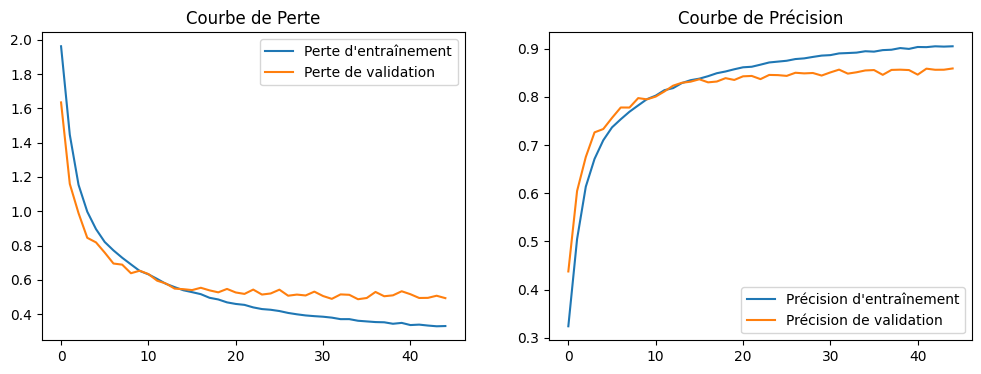

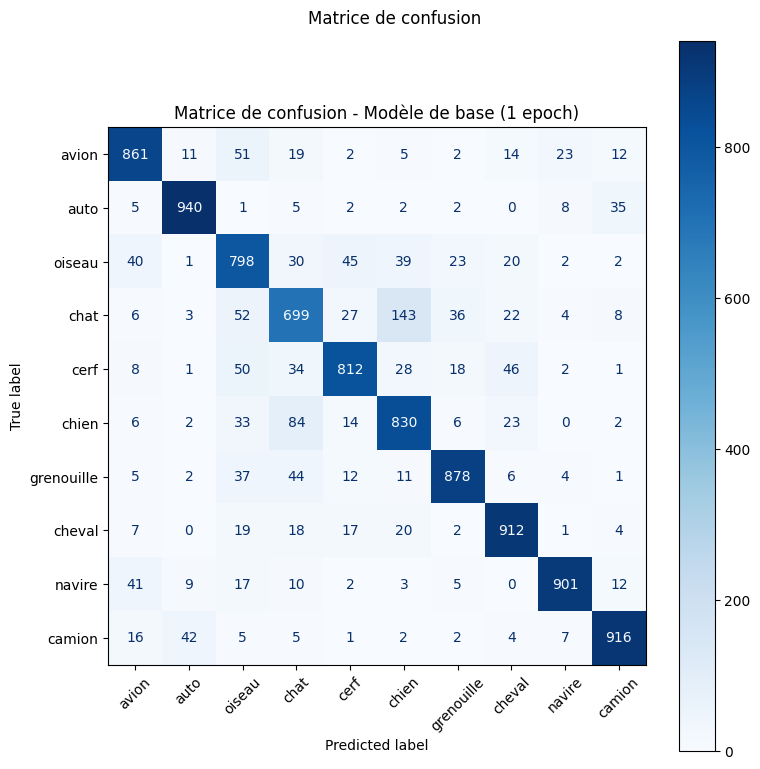

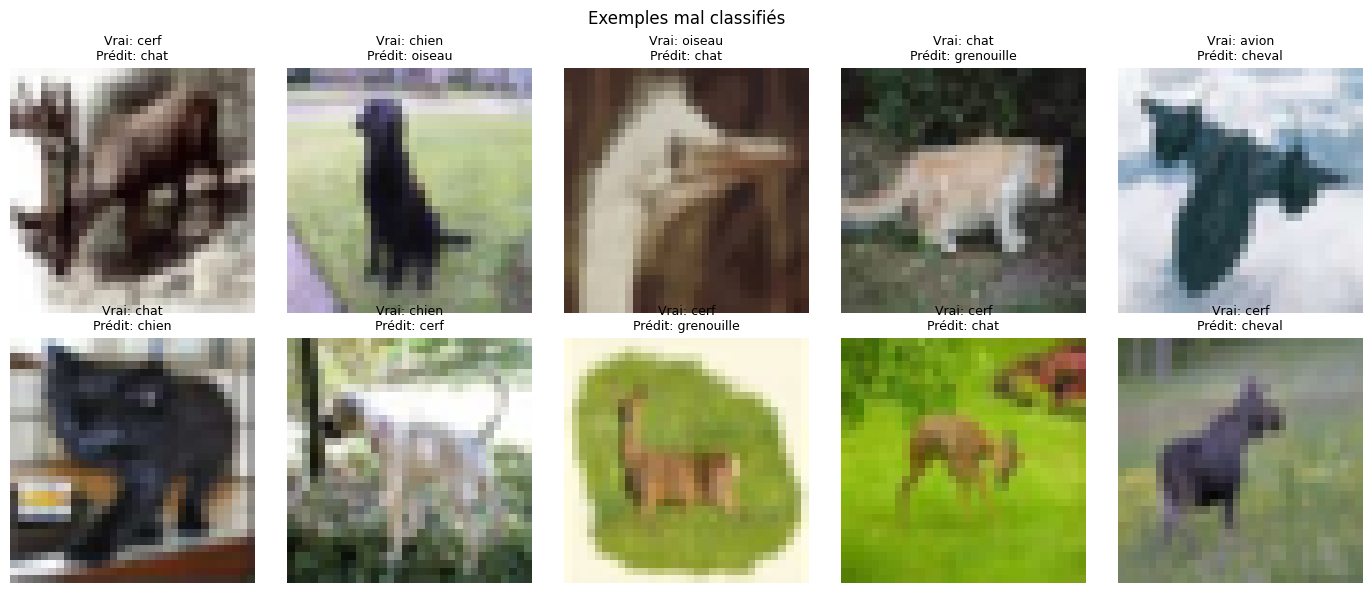

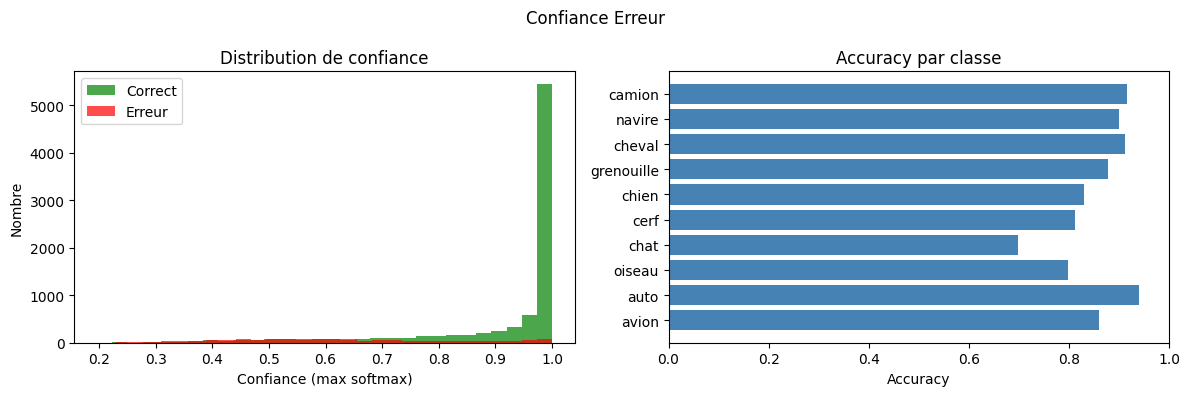

76996

In [13]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(0.01)
# - doublement de Conv2D
# - doublement de Dense

model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False, activation='swish'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, activation='swish', kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  41/1563 [..............................] - ETA: 6s - loss: 2.5468 - accuracy: 0.1715

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1563/1563 [==============================] - 8s 4ms/step - loss: 1.5660 - accuracy: 0.4524 - val_loss: 1.8588 - val_accuracy: 0.4611
Epoch 2/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.0887 - accuracy: 0.6352 - val_loss: 0.9379 - val_accuracy: 0.6893
Epoch 3/100
1563/1563 [==============================] - 6s 4ms/step - loss: 0.9324 - accuracy: 0.6911 - val_loss: 0.8108 - val_accuracy: 0.7337
Epoch 4/100
1563/1563 [==============================] - 6s 4ms/step - loss: 0.8365 - accuracy: 0.7236 - val_loss: 0.7633 - val_accuracy: 0.7497
Epoch 5/100
1563/1563 [==============================] - 6s 4ms/step - loss: 0.7762 - accuracy: 0.7450 - val_loss: 0.7948 - val_accuracy: 0.7393
Epoch 6/100
1563/1563 [==============================] - 6s 4ms/step - loss: 0.7256 - accuracy: 0.7649 - val_loss: 0.6436 - val_accuracy: 0.7957
Epoch 7/100
1563/1563 [==============================] - 6s 4ms/step - loss: 0.6819 - accuracy: 0.7812 - val_loss: 0.6346 - val_accuracy: 0.79

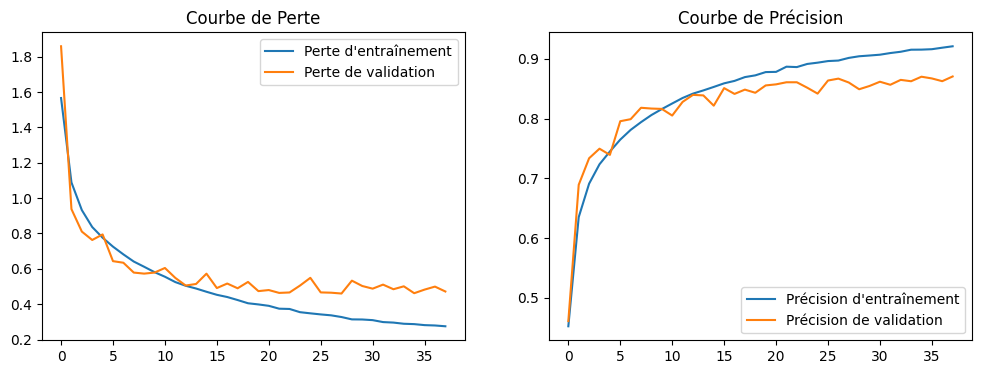

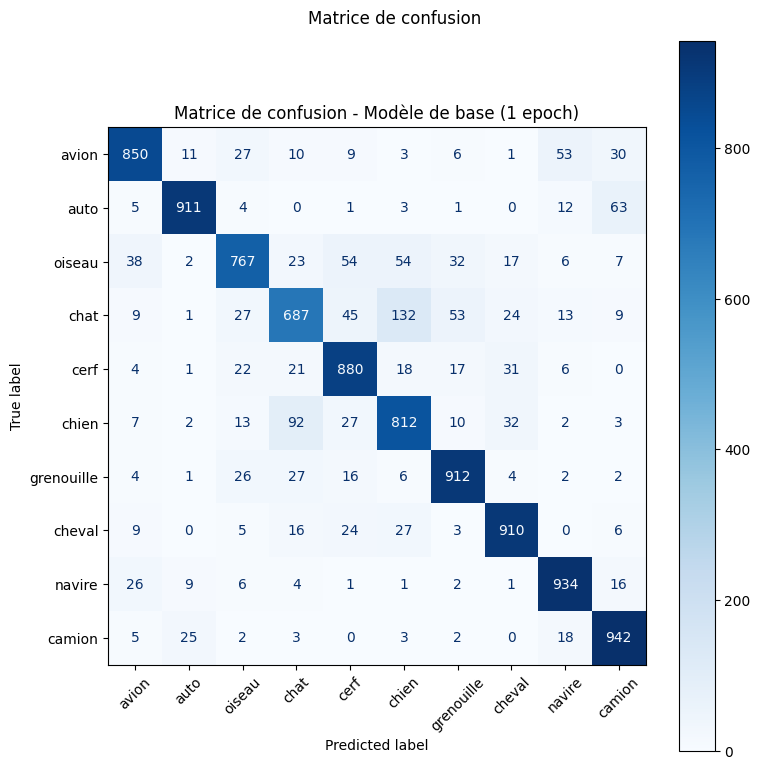

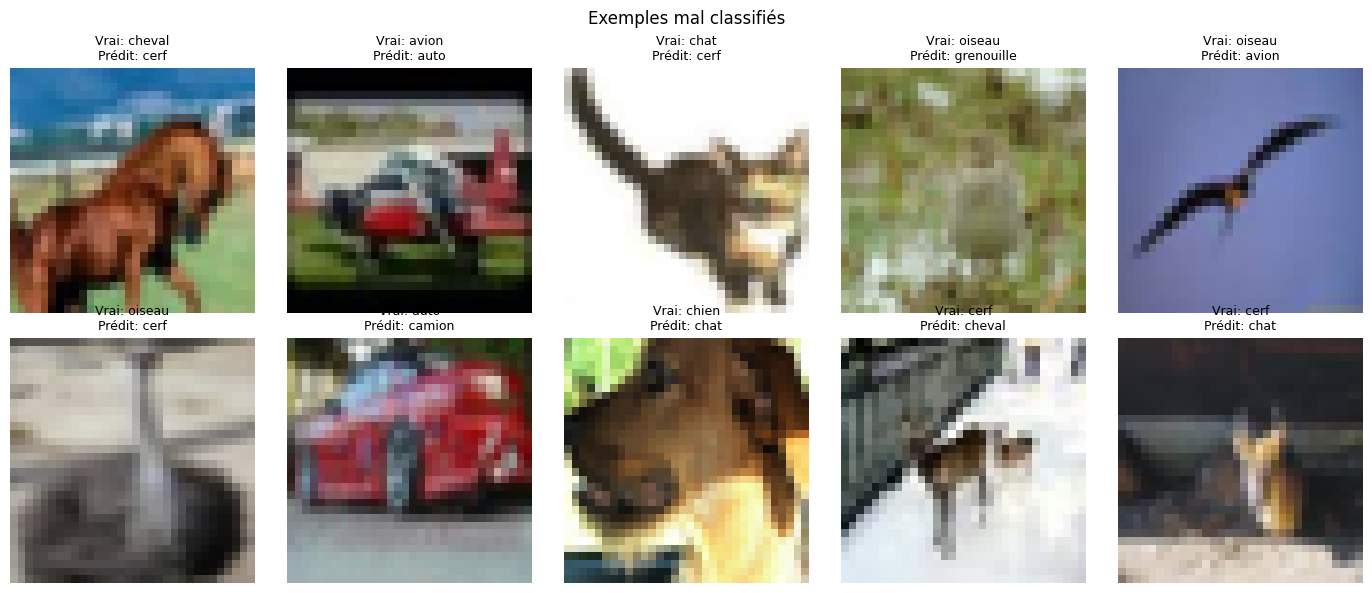

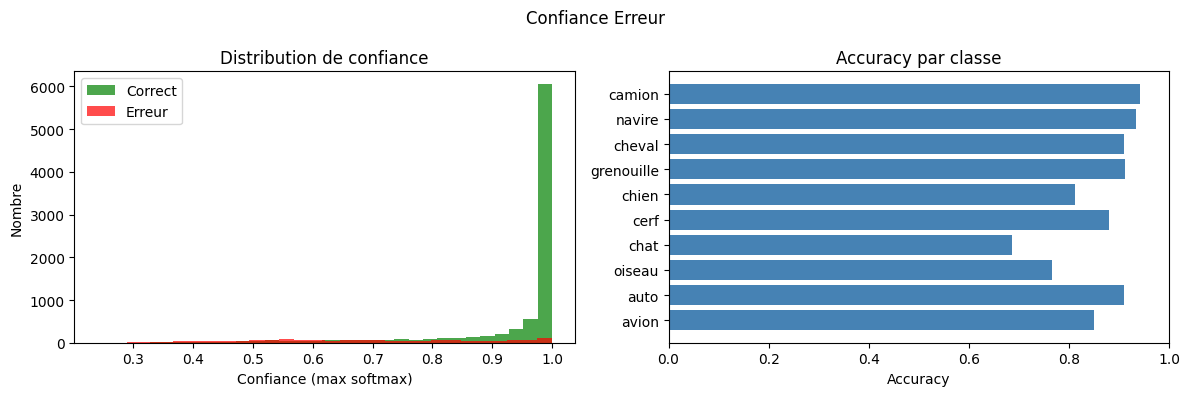

70627

In [16]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(0.01)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping


model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  39/1563 [..............................] - ETA: 6s - loss: 2.5283 - accuracy: 0.1899

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1563/1563 [==============================] - 8s 4ms/step - loss: 1.5305 - accuracy: 0.4644 - val_loss: 1.1819 - val_accuracy: 0.6010 - lr: 0.0100
Epoch 2/100
1563/1563 [==============================] - 6s 4ms/step - loss: 1.0848 - accuracy: 0.6328 - val_loss: 0.9019 - val_accuracy: 0.7016 - lr: 0.0100
Epoch 3/100
1563/1563 [==============================] - 6s 4ms/step - loss: 0.9359 - accuracy: 0.6890 - val_loss: 0.7758 - val_accuracy: 0.7411 - lr: 0.0100
Epoch 4/100
1563/1563 [==============================] - 6s 4ms/step - loss: 0.8449 - accuracy: 0.7218 - val_loss: 0.7142 - val_accuracy: 0.7732 - lr: 0.0100
Epoch 5/100
1563/1563 [==============================] - 6s 4ms/step - loss: 0.7773 - accuracy: 0.7459 - val_loss: 0.6791 - val_accuracy: 0.7835 - lr: 0.0100
Epoch 6/100
1563/1563 [==============================] - 6s 4ms/step - loss: 0.7269 - accuracy: 0.7622 - val_loss: 0.6255 - val_accuracy: 0.7990 - lr: 0.0100
Epoch 7/100
1563/1563 [==============================] - 6s 4ms/

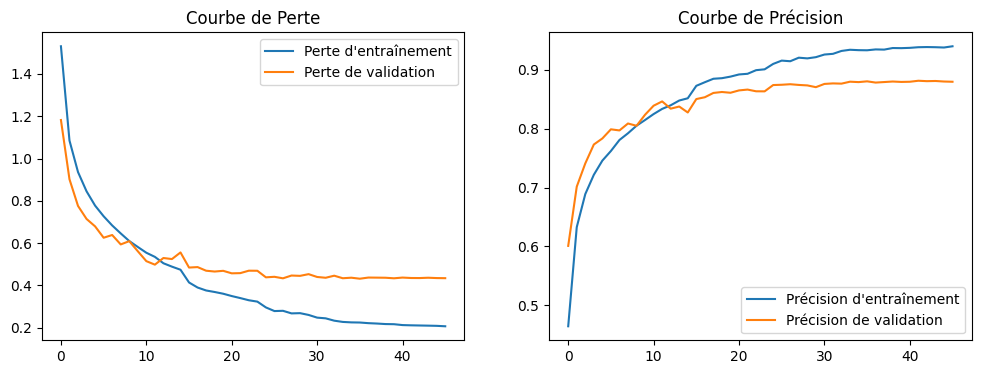

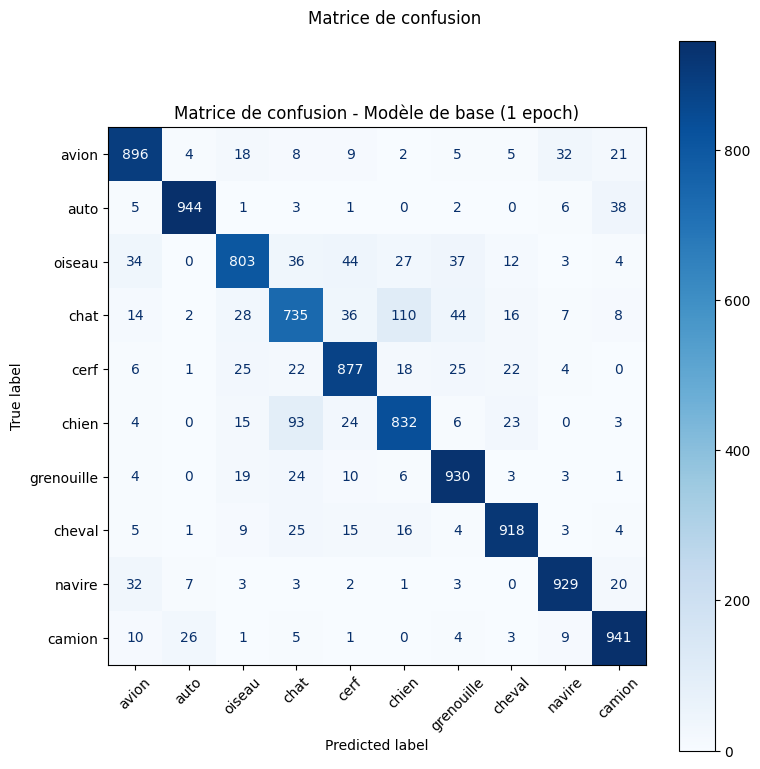

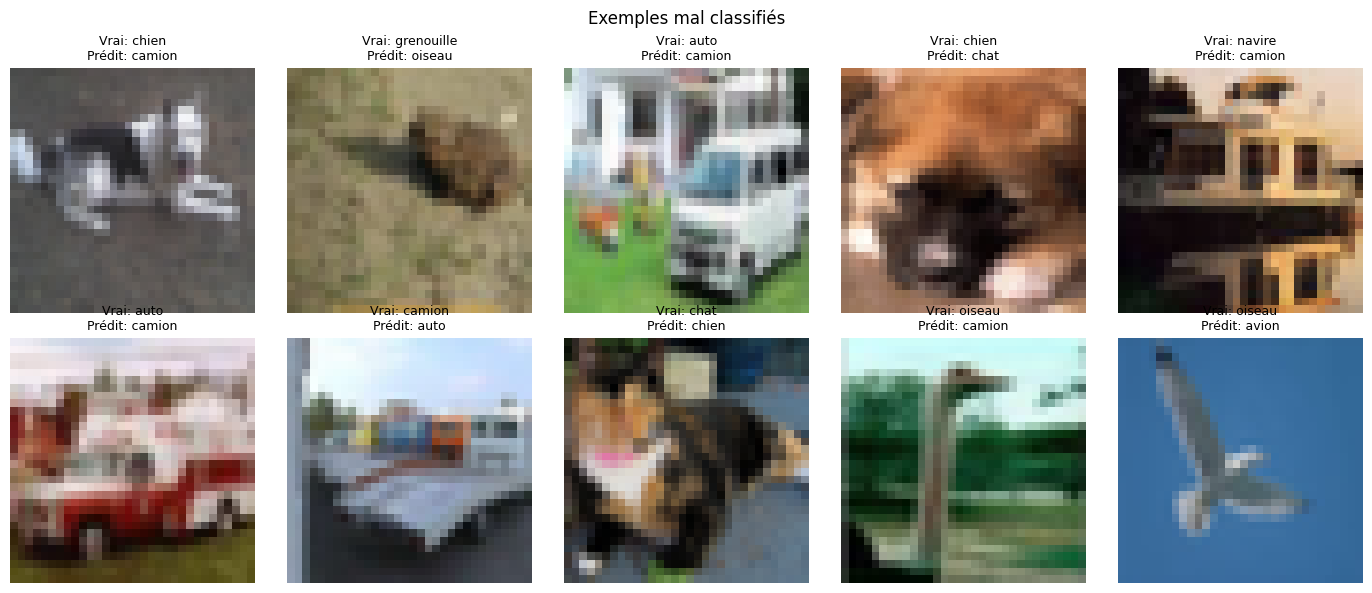

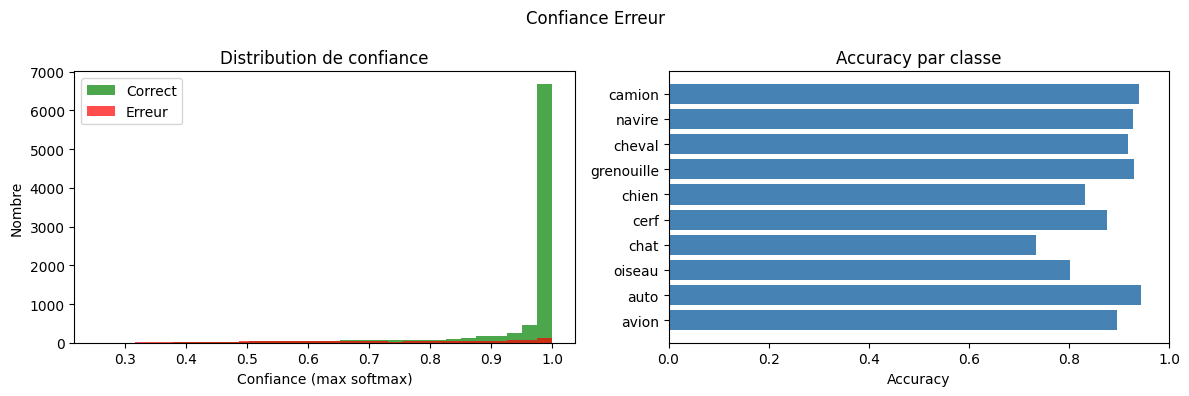

79861

In [17]:
# Définition du modèle CNN avec :
# - BatchNormalisation(use_bias=False), 
# - Dropout(0.25, 0.5), 
# - activation="swish", 
# - optimizer SGD avec momentum,
# - padding='same'
# - kernel_regularizer=keras.regularizers.l2(0.01)
# - doublement de Conv2D
# - doublement de Dense
# - inversion position activation et batchnormalisation
# - ajout d'une activation elu et batchnormalisation dans la dernière couche dense
# - ajout du callback EarlyStopping 
# - ajout du callback ReduceLROnPlateau


model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False, input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(32, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Conv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, kernel_regularizer=keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('swish'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

# Entraînement rapide pour test (les étudiants complèteront)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)

# Évaluation du modèle
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Précision sur l’ensemble de test : {test_acc:.4f}')

# Prediciton Basique
y_pred = model.predict(x_test).argmax(axis=1)
y_proba = model.predict(x_test)

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, model
gc.collect()

Epoch 1/100
  21/1563 [..............................] - ETA: 3s - loss: 2.2868 - accuracy: 0.1577   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1563/1563 [==============================] - 6s 3ms/step - loss: 1.3719 - accuracy: 0.5218 - val_loss: 1.2469 - val_accuracy: 0.5608
Epoch 2/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.1892 - accuracy: 0.5844 - val_loss: 1.1918 - val_accuracy: 0.5818
Epoch 3/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.1322 - accuracy: 0.6044 - val_loss: 1.1785 - val_accuracy: 0.5898
Epoch 4/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.0911 - accuracy: 0.6207 - val_loss: 1.1454 - val_accuracy: 0.5980
Epoch 5/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.0604 - accuracy: 0.6287 - val_loss: 1.1266 - val_accuracy: 0.6079
Epoch 6/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.0302 - accuracy: 0.6388 - val_loss: 1.1324 - val_accuracy: 0.6041
Epoch 7/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.0023 - accuracy: 0.6497 - val_loss: 1.1291 - val_accuracy: 0.60

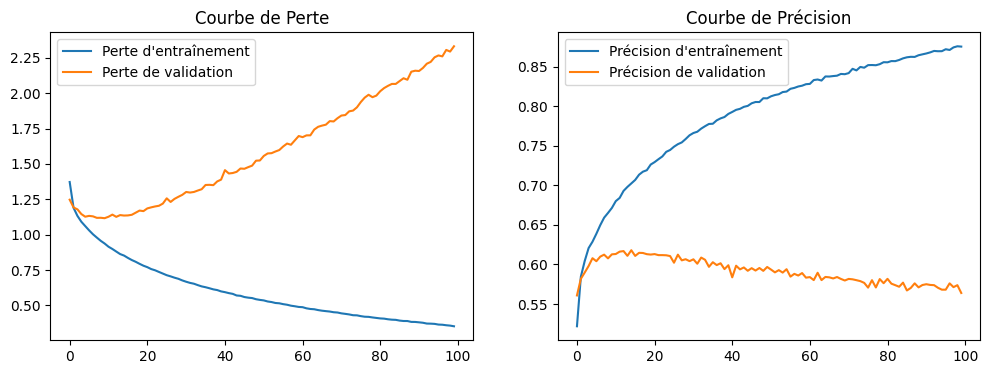

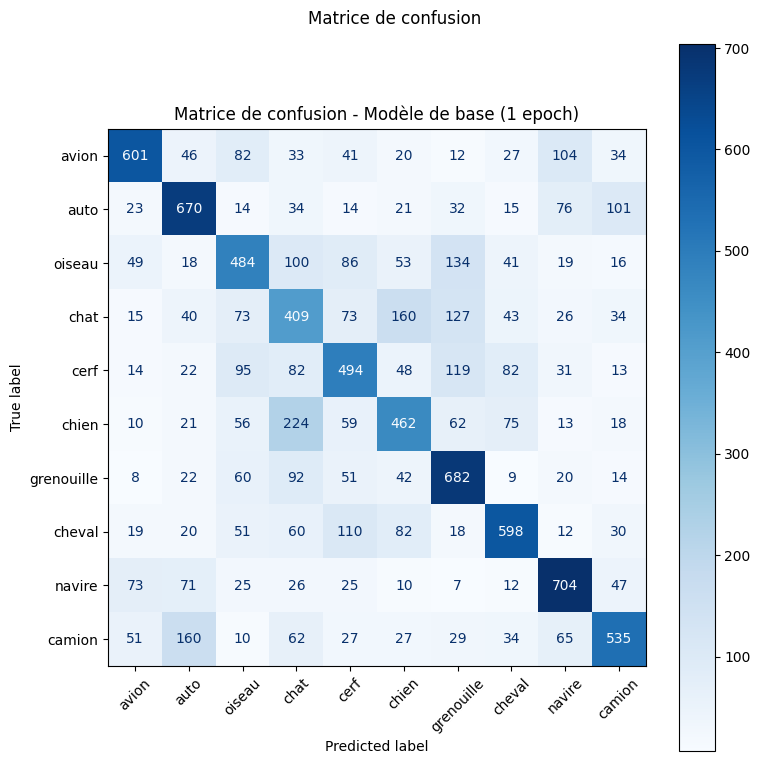

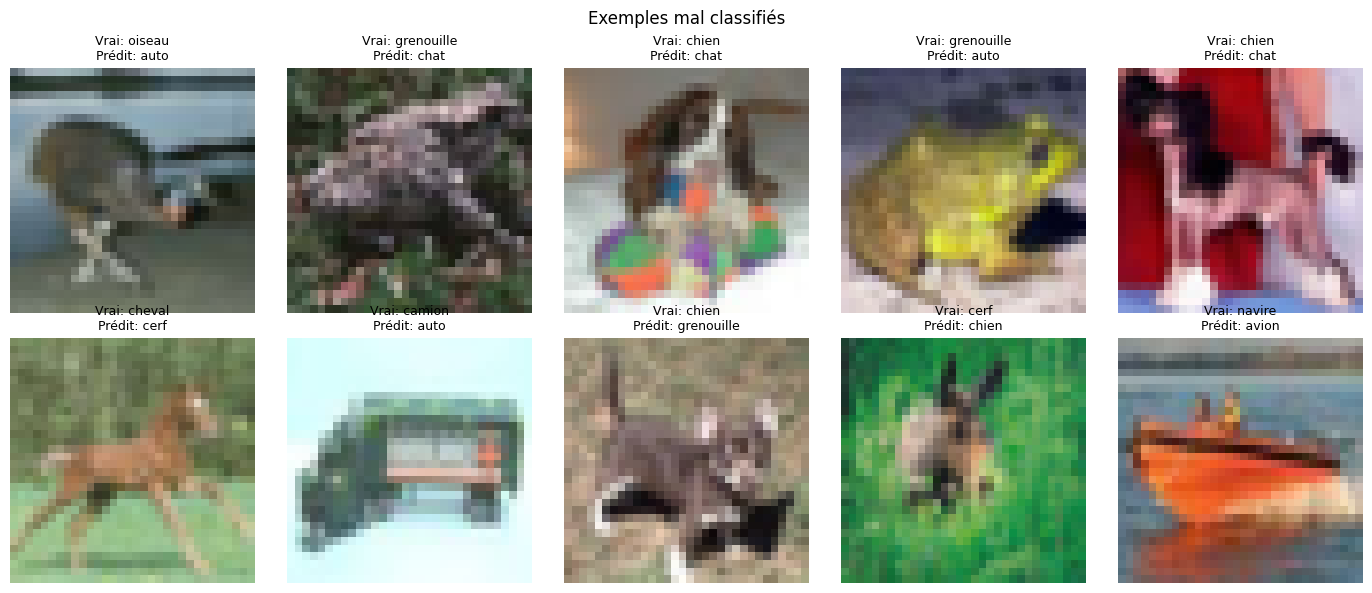

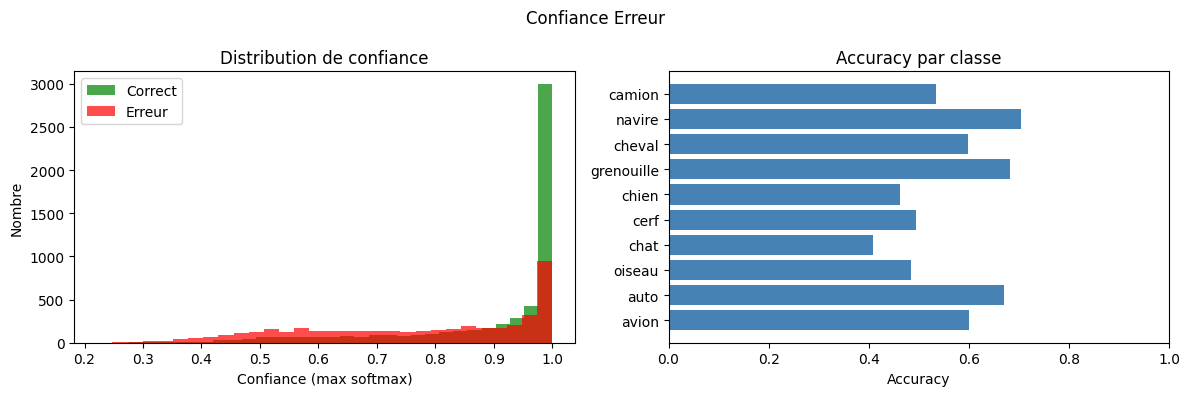

100856

In [21]:
# Question pour expérimenter l'Apprentissage par Transfert

# Charger le modèle pré-entraîné  VGG16
base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Geler les poids du modèle pré-entraîné

# Ajouter une couche de classification personnalisée
transfer_model = keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compilation et entraînement du modèle avec transfert d’apprentissage
transfer_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Entraînement rapide pour test
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = transfer_model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test))
y_pred = transfer_model.predict(x_test).argmax(axis=1)
y_proba = transfer_model.predict(x_test)

# Comparer la performance avec et sans transfert d’apprentissage
test_loss_transfer, test_acc_transfer = transfer_model.evaluate(x_test, y_test, verbose=2)
print(f'Précision avec apprentissage par transfert : {test_acc_transfer:.4f}')

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, transfer_model
gc.collect()

Epoch 1/100
   1/1563 [..............................] - ETA: 19:50 - loss: 2.5253 - accuracy: 0.0625

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1563/1563 [==============================] - 6s 3ms/step - loss: 1.4920 - accuracy: 0.4765 - val_loss: 1.2738 - val_accuracy: 0.5570
Epoch 2/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.2971 - accuracy: 0.5446 - val_loss: 1.2251 - val_accuracy: 0.5630
Epoch 3/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.2511 - accuracy: 0.5628 - val_loss: 1.1847 - val_accuracy: 0.5868
Epoch 4/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.2085 - accuracy: 0.5778 - val_loss: 1.1648 - val_accuracy: 0.5915
Epoch 5/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.1863 - accuracy: 0.5852 - val_loss: 1.1484 - val_accuracy: 0.6005
Epoch 6/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.1666 - accuracy: 0.5902 - val_loss: 1.1444 - val_accuracy: 0.6004
Epoch 7/100
1563/1563 [==============================] - 5s 3ms/step - loss: 1.1541 - accuracy: 0.5964 - val_loss: 1.1369 - val_accuracy: 0.59

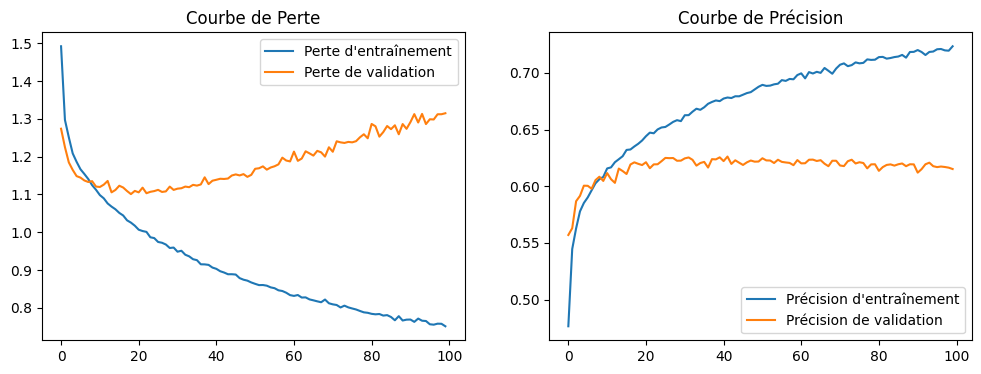

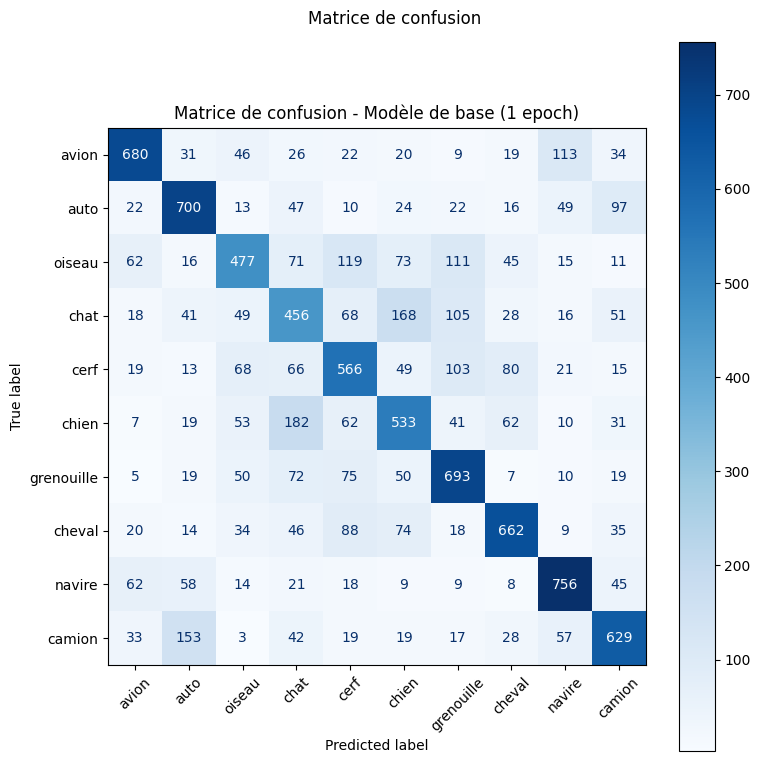

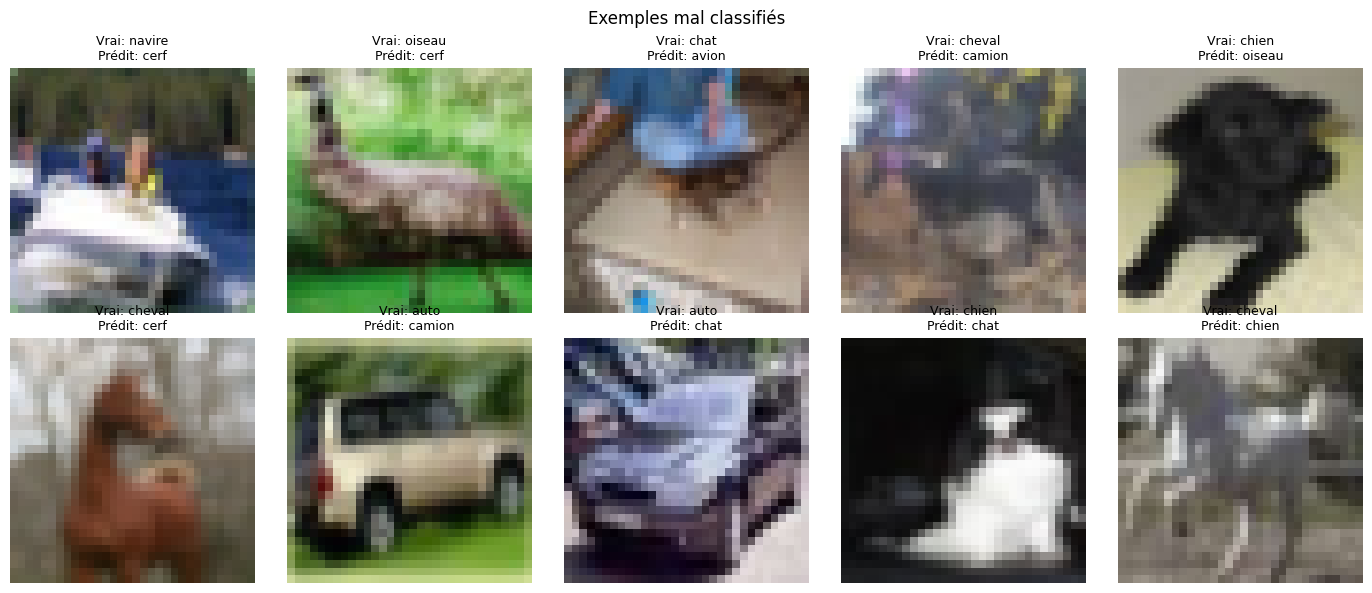

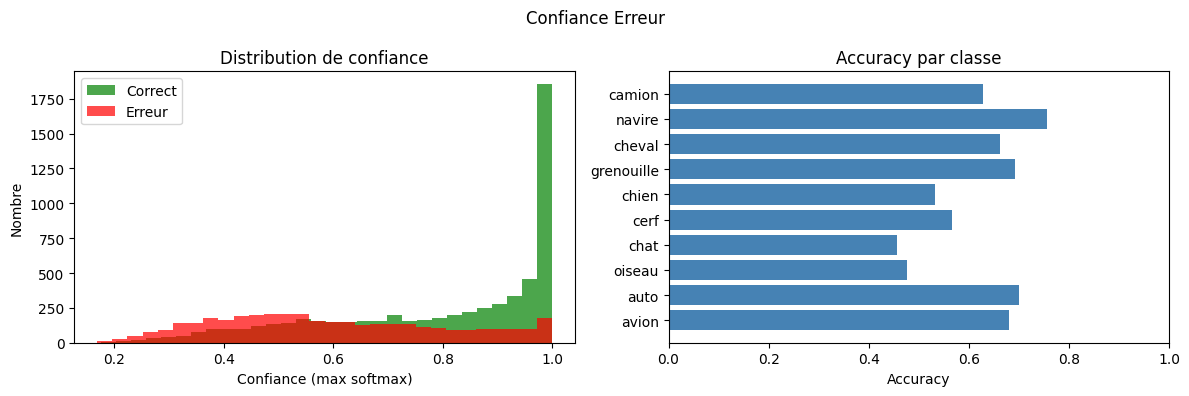

103140

In [ ]:
# Question pour expérimenter l'Apprentissage par Transfert

# Charger le modèle pré-entraîné  VGG16
base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Geler les poids du modèle pré-entraîné

# Ajouter une couche de classification personnalisée
transfer_model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation et entraînement du modèle avec transfert d’apprentissage
transfer_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Entraînement rapide pour test
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = transfer_model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)
y_pred = transfer_model.predict(x_test).argmax(axis=1)
y_proba = transfer_model.predict(x_test)

# Comparer la performance avec et sans transfert d’apprentissage
test_loss_transfer, test_acc_transfer = transfer_model.evaluate(x_test, y_test, verbose=2)
print(f'Précision avec apprentissage par transfert : {test_acc_transfer:.4f}')

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, transfer_model
gc.collect()

Epoch 1/100
   1/1563 [..............................] - ETA: 11:56 - loss: 2.8214 - accuracy: 0.0938

W0000 00:00:1775881866.964635    3919 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881866.964790    3919 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881866.964916    3919 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881866.965067    3919 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881866.965204    3919 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881866.965354    3919 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881866.965568    3919 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881866.965729    3919 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881866.965949    3919 gp

1563/1563 [==============================] - ETA: 0s - loss: 1.3223 - accuracy: 0.5381

W0000 00:00:1775881873.119574    3907 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881873.119680    3907 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881873.119752    3907 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881873.119852    3907 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881873.119936    3907 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881873.120031    3907 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881873.120104    3907 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881873.120201    3907 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1775881873.120283    3907 gp

1563/1563 [==============================] - 8s 5ms/step - loss: 1.3223 - accuracy: 0.5381 - val_loss: 1.0555 - val_accuracy: 0.6369 - lr: 0.0010
Epoch 2/100
1563/1563 [==============================] - 7s 5ms/step - loss: 1.0774 - accuracy: 0.6250 - val_loss: 0.9842 - val_accuracy: 0.6574 - lr: 0.0010
Epoch 3/100
1563/1563 [==============================] - 7s 5ms/step - loss: 1.0191 - accuracy: 0.6474 - val_loss: 0.9451 - val_accuracy: 0.6698 - lr: 0.0010
Epoch 4/100
1563/1563 [==============================] - 7s 5ms/step - loss: 0.9834 - accuracy: 0.6582 - val_loss: 0.9409 - val_accuracy: 0.6671 - lr: 0.0010
Epoch 5/100
1563/1563 [==============================] - 7s 5ms/step - loss: 0.9590 - accuracy: 0.6647 - val_loss: 0.9121 - val_accuracy: 0.6826 - lr: 0.0010
Epoch 6/100
1563/1563 [==============================] - 7s 5ms/step - loss: 0.9364 - accuracy: 0.6752 - val_loss: 0.9007 - val_accuracy: 0.6846 - lr: 0.0010
Epoch 7/100
1563/1563 [==============================] - 7s 5ms/

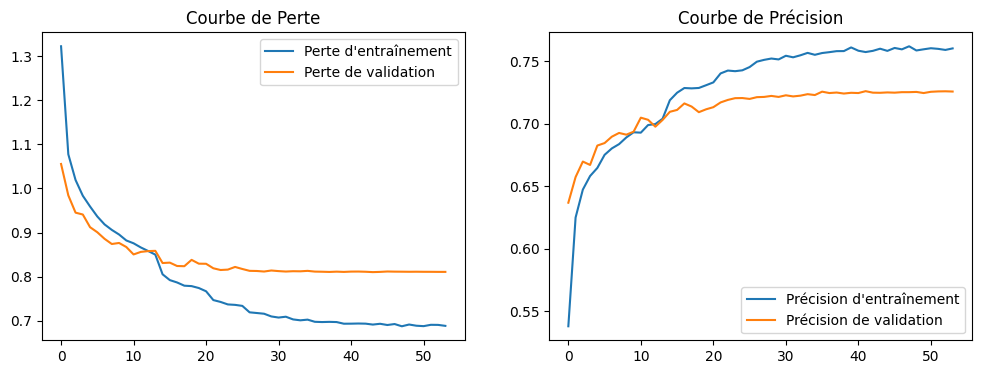

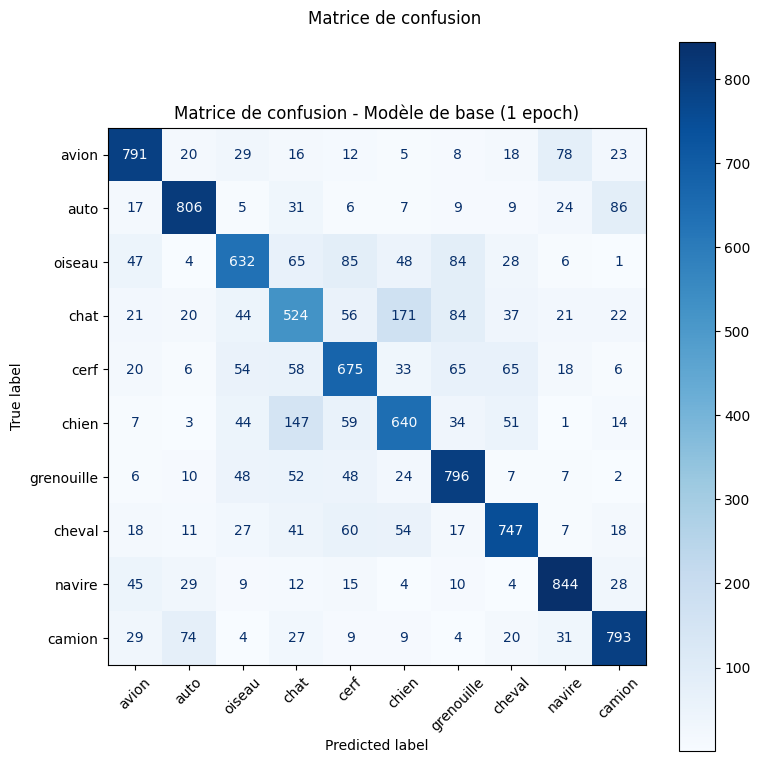

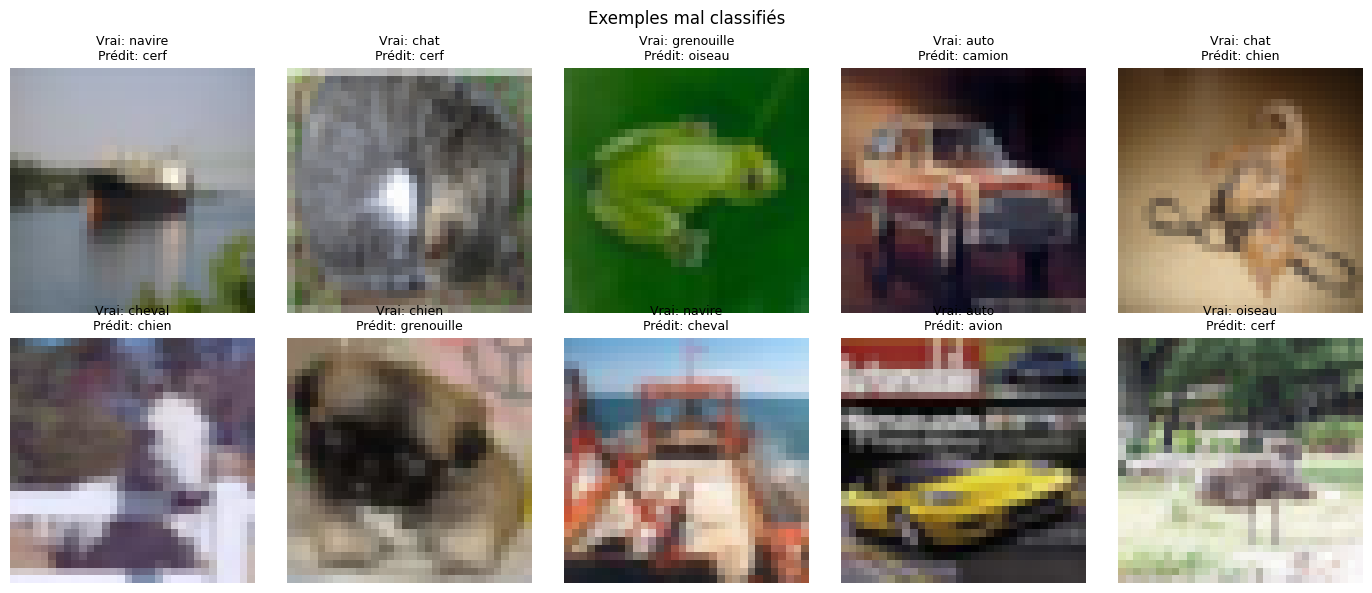

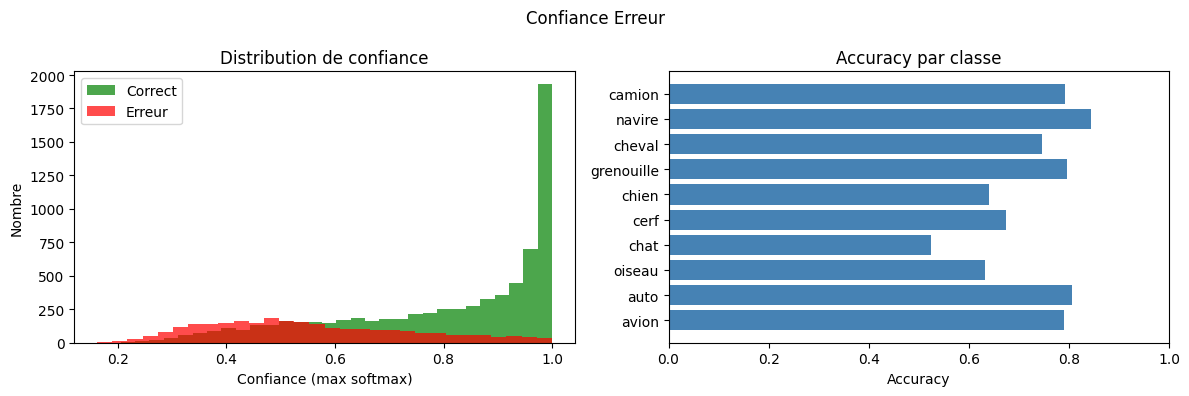

85079

In [31]:
# Question pour expérimenter l'Apprentissage par Transfert

# Charger le modèle pré-entraîné  VGG16
base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False  # Geler les poids du modèle pré-entraîné

# Ajouter une couche de classification personnalisée
transfer_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Resizing(96, 96),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilation et entraînement du modèle avec transfert d’apprentissage
transfer_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Entraînement rapide pour test
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]
history_fit = transfer_model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test), callbacks=callbacks)
y_pred = transfer_model.predict(x_test).argmax(axis=1)
y_proba = transfer_model.predict(x_test)

# Comparer la performance avec et sans transfert d’apprentissage
test_loss_transfer, test_acc_transfer = transfer_model.evaluate(x_test, y_test, verbose=2)
print(f'Précision avec apprentissage par transfert : {test_acc_transfer:.4f}')

# Courbes d'apprentissage
learning_curve(history_fit)
# Matrice de confusion du modèle de base
confusion_matrices(y_pred, y_test)
# Exemples d\'erreurs de classification
classification_error_samples(y_pred, x_test, y_test)
# Confiance du modèle sur les erreurs
error_confidence(y_proba, y_pred, y_test)
del y_proba, y_pred, history_fit, transfer_model
gc.collect()